# Preprocesado del Dataset

Esta sección del notebook se centra en la preparación de los datos para el entrenamiento del modelo de detección de objetos. 

* **Paso 1:** Mitigación de Falsos Positivos mediante Inyección de imágenes de fondo sin objetos (espacios libres) en el dataset. 

* **Paso 2:** Redimensionamiento uniforme: Las 65 resoluciones diferentes del dataset se deben normalizar a 640x640 (letterbox para preservar aspect ratio) para crear batches de entrenamiento uniformes.

* **Paso 3:** Split del Dataset (train/valid/test) estratificadas.

* **Paso 4:** Analizar la distribución de clases del set train para detectar posibles desbalances y aplicar técnicas de augmentación si es necesario.

* **Paso 5:** Guardar el Dataset Preprocesado en Formato YOLO, COCO y TFrecord para su uso en diferentes frameworks de entrenamiento.

In [1]:
# Auto-reload: recarga módulos automáticamente al detectar cambios en disco
%load_ext autoreload
%autoreload 2

# Librerías
import os
import sys
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import hashlib
import yaml
from pycocotools.coco import COCO
from sklearn.cluster import KMeans
from pathlib import Path
import zipfile

# Rutas base
base_dir = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS"

# Añadir path de utilidades
src_path = os.path.join(base_dir, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils_eda import *
from utils_preprocessing import *

# Directorio de salida para guardar reportes
output_dir = os.path.join(base_dir, "Reports", "Process_Dataset_OIDC_original_v2")

In [2]:
# Descomprimir el Dataset
dataset_path = os.path.join(base_dir, "Datasets", "dataset_IODC_original_3")

# Descomprimir el Dataset
unzip_datasets(source_dir=dataset_path)

Se encontraron 1 archivos .zip
--------------------------------------------------

Descomprimiendo: IODC-background-yolo26.zip
Destino: IODC-background-yolo26/
✓ Completado - 2501 archivos extraídos

Proceso completado


🔧 Procesamiento de Dataset YOLO
   📂 Origen:  /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/IODC-background-yolo26
   📂 Destino: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3

📂 Fase 1: Descubrimiento de clases...

   📋 Mapeo global unificado:
      0: dog
      1: door
      2: obstacle
      3: person
      4: stair

   Total de clases únicas: 5

   📊 Traducción de clases:
      0:'dog' → 0:'dog' (sin cambio)
      1:'door' → 1:'door' (sin cambio)
      2:'obstacle' → 2:'obstacle' (sin cambio)
      3:'person' → 3:'person' (sin cambio)
      4:'stair' → 4:'stair' (sin cambio)

📁 Fase 2: Creando estructura de destino...
   ✅ /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/data/images
   ✅ /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/data/labels

🚚 Fase 3: Procesando imágenes y labels...
   Splits encontrados: ['train']
   ✅ train: 1249 imágenes procesadas

   

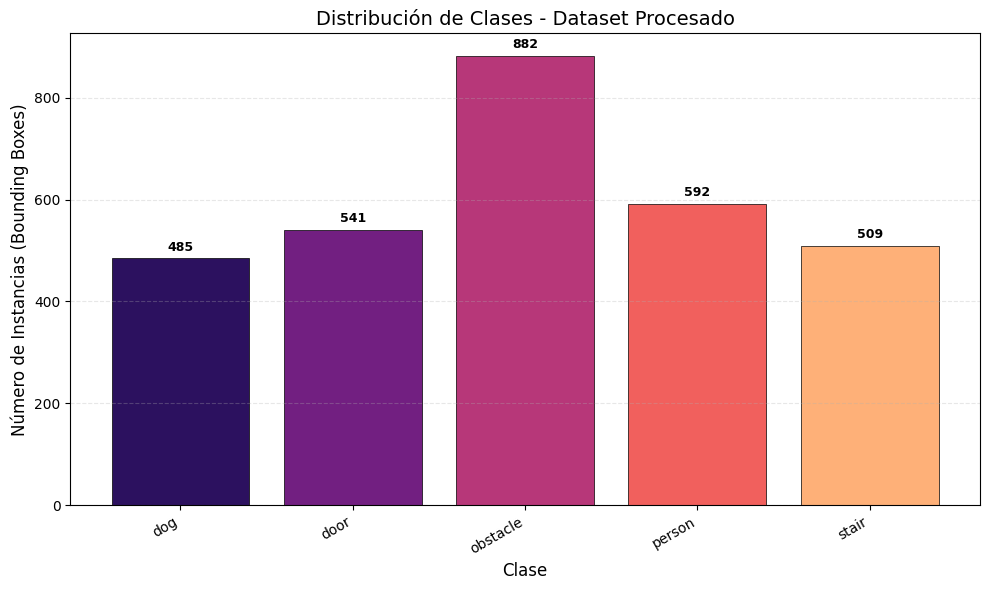


   💾 Gráfica guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/class_distribution.png

✅ PROCESAMIENTO COMPLETADO
   📂 Directorio: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3
   🖼  Imágenes:  1,249
   🏷  Clases:    5 → ['dog', 'door', 'obstacle', 'person', 'stair']
   📦 BB totales: 3,009



In [3]:
# Ruta del dataset descomprimido (con data.yaml + train/images + train/labels)
dataset_path_unzip = os.path.join(dataset_path, "IODC-background-yolo26")

# Procesar dataset YOLO: normalizar clases, serializar imágenes, reestructurar a data/images + data/labels
stats = process_yolo_dataset(
    dataset_path=dataset_path_unzip,
    output_dir=dataset_path,
    class_overrides={"escalator": "stair"},
    output_dir_reports=output_dir
)

---

## Paso 1: Mitigación de Falsos Positivos

El EDA determinó que la totalidad de las imágenes originales contenían al menos un objeto anotado, factor que incrementa el riesgo de "alucinación" de objetos en espacios vacíos dentro de un entorno doméstico. En consecuencia, la literatura reciente demuestra que integrar entre el 10% y el 15% de muestras de fondo (De 112 a 168 imágenes, en el caso actual), permiten al modelo reconocer el ruido visual de interiores como una clase de relleno, optimizando la precisión al reducir la tasa de falsos positivos (Lee et al., 2025; Glez-Peña et al., 2023; ). Más aún en dispositivos de borde (Edge AI) como el ESP32-S3, donde se manejan resoluciones bajas y los píxeles de fondo pueden biselarse y parecerse a los objetos de interés.

* **Composición y Criterios Técnicos de las Muestras de Fondo:**  Para asegurar la eficacia de esta inyección, las imágenes son capturadas en el entorno desde la perspectiva egocéntrica del robot, centrándose en texturas y geometrías permanentes del contexto real. Las tomas incluyen planos de tierra despejados (Ej. baldosas), intersecciones entre paredes y suelos para evitar confusiones con bordes de muebles, y espacios de transición vacíos. Se mantienen los mismos criterios técnicos generales del dataset original.

* **Metodología de Obtención y Validación de Integridad:** La generación de este subconjunto se realizó mediante dos vías complementarias: la captura real, utilizando la interfaz de control del robot para obtener ráfagas en zonas vacías, y la generación sintética mediante modelos de inteligencia artificial ajustados a una resolución de 640×640.


Finalmente, se garantizó que estas imágenes se estuviesen estrictamente "limpias" de etiquetas. La presencia de elementos no catalogados —como la sección de un mueble no etiquetada— enviaría señales contradictorias al sistema, indicando erróneamente que un objeto de interés debe ser interpretado como fondo. Como resultado final se obtuvo:

* **Dataset_Background_1:** 87 Fotos tomadas desde la ESP32-S3 + CAM OV5640 a resolución FRAMSIZE_QVGA 800x600 pixeles [iluminación variable].

* **Dataset_Background_2:** 38 imágenes sintéticas a resoluciones variables [escenarios creados totalmente desde cero con instrucciones basadas en los criterios técnicos objetivo].


In [4]:
# Variables necesarias
coco, img_dir = load_yolo_as_coco(dataset_path)
img_ids = coco.getImgIds()
target_cat_ids = coco.getCatIds()
id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(target_cat_ids)}
# Asignar colores automáticamente a cada clase
_color_pool = [
    (255, 0, 0),      # Rojo
    (0, 255, 0),      # Verde
    (0, 0, 255),      # Azul
    (255, 255, 0),    # Cyan/Amarillo
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Amarillo (BGR)
]
class_colors = {name: _color_pool[i % len(_color_pool)] for i, name in enumerate(id_to_name.values())}
density_counts, ious = calculate_density_and_iou(coco, target_cat_ids)
images_bg = [coco.loadImgs(img_id)[0]['file_name'] for img_id, count in zip(img_ids, density_counts) if count == 0]

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Dataset YOLO cargado como COCO:
   📂 Imágenes: 1249
   📝 Anotaciones: 3009
   🏷️  Categorías: ['dog', 'door', 'obstacle', 'person', 'stair']
Procesando imágenes para calcular IoU y Densidad...


In [8]:
print(f" Se tienen {density_counts.count(0)} imágenes sin objetos o background, lo que representa el {density_counts.count(0) / len(img_ids) * 100:.2f}% del total de imágenes.")

 Se tienen 125 imágenes sin objetos o background, lo que representa el 10.01% del total de imágenes.


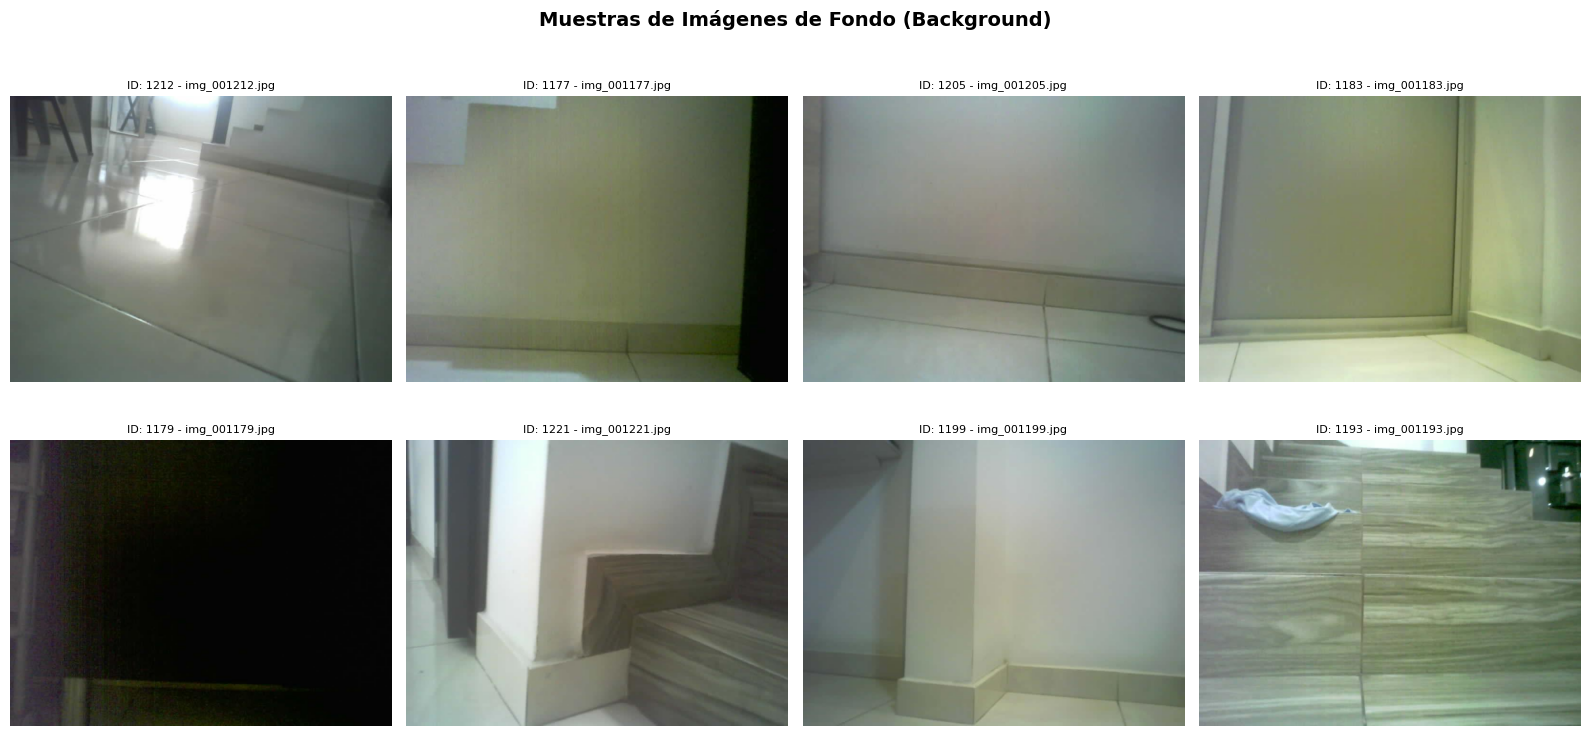

In [12]:
# Obtener IDs de imágenes de fondo (sin objetos)
bg_img_ids = [img_id for img_id, count in zip(img_ids, density_counts) if count == 0]

# Seleccionar 8 aleatorios
sample_ids = random.sample(bg_img_ids, min(8, len(bg_img_ids)))

# Visualizar usando visualize_sample
base_img_dir = os.path.join(dataset_path, "data", "images")

# Llamar a visualize_sample pasando la lista de IDs seleccionados
visualize_sample(
    coco=coco,
    target_cat_ids=target_cat_ids,
    id_to_name=id_to_name,
    class_colors=class_colors,
    img_dir=base_img_dir,
    num_samples=len(sample_ids),
    img_ids=sample_ids,
    filename='02_visual_sample_background_images.png',
    title="Muestras de Imágenes de Fondo (Background)"
)

---

## Paso 2: Redimensionamiento uniforme 

Las 65 resoluciones diferentes del dataset se deben normalizar a 640x640 (letterbox para preservar aspect ratio) para crear batches de entrenamiento uniformes.

In [15]:
# Extraer dimensiones de todas las imágenes
splits = {'all': coco}
df_dimensions = get_image_dimensions(splits)
display(df_dimensions.head())

# Normalización dimensional a 640x640 usando Letterbox (con padding gris)
input_coco_json = os.path.join(dataset_path, "_annotations.coco.json")
input_images_dir = img_dir
letterbox_output_dir = os.path.join(dataset_path, "letterbox_640")

summary_letterbox = letterbox_coco_dataset_offline(
    coco_json_path=input_coco_json,
    images_dir=input_images_dir,
    output_dir=letterbox_output_dir,
    output_json_name="_annotations.letterbox.coco.json",
    target_size=(640, 640),
    padding_color=(114, 114, 114),
)

display(pd.DataFrame([summary_letterbox]))

# Validación rápida: debe haber una sola resolución (640x640)
output_json_path = str(summary_letterbox["output_json_path"])
dims_check = summarize_image_dimensions_from_coco(output_json_path)
print("\nValidación de resoluciones:")
print(dims_check)

,image_id,width,height,split
0,1,512,379,all
1,2,508,371,all
2,3,508,375,all
3,4,1024,765,all
4,5,1024,765,all


📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640
📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640/data/images

🧩 Iniciando normalización Letterbox COCO...
   📄 JSON entrada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/_annotations.coco.json
   🖼️  Imágenes entrada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/data/images
   📦 Salida: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640
   🔄 Progreso: 200/1249 imágenes revisadas
   🔄 Progreso: 400/1249 imágenes revisadas
   🔄 Progreso: 600/1249 imágenes revisadas
   🔄 Progreso: 800/1249 imágenes revisadas
   🔄 Progreso: 1000/1249 imágenes revisadas
   🔄 Progreso: 1200/1249 imágenes revisadas

✅ Letterbox offline completado
   🖼️  Imágenes procesadas: 1249
   ⚠️  Imágenes faltantes: 0
   ⚠️  Imágenes no legi

,output_json_path,output_images_dir,processed_images,missing_images,unreadable_images,input_annotations,output_annotations,removed_annotations,target_size,padding_color
0,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,1249,0,0,3009,3009,0,"(640, 640)","(114, 114, 114)"



Validación de resoluciones:
{'num_images': 1249, 'num_unique_resolutions': 1}


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/03_visual_sample_letterbox_images.png.png


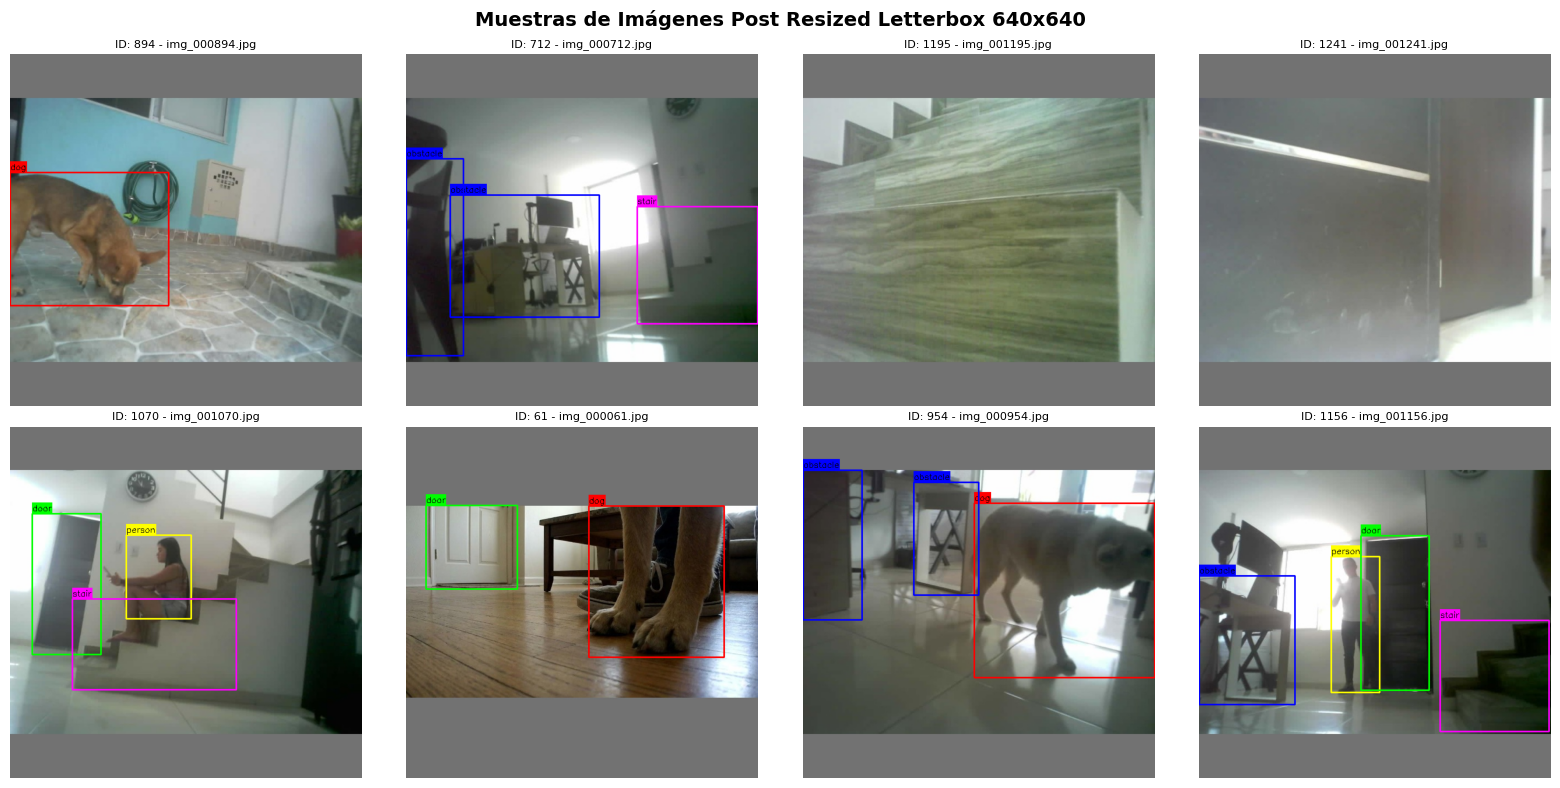

✅ Se visualizaron 8 imágenes desde: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640/data/images


In [24]:
# Visualizar sample de 8 imágenes del dataset Letterbox
letterbox_json_path = os.path.join(letterbox_output_dir, "_annotations.letterbox.coco.json")
letterbox_img_dir = os.path.join(letterbox_output_dir, "data", "images")

if not os.path.exists(letterbox_json_path):
    raise FileNotFoundError(f"No se encontró el JSON letterbox: {letterbox_json_path}")
if not os.path.exists(letterbox_img_dir):
    raise FileNotFoundError(f"No se encontró el directorio de imágenes letterbox: {letterbox_img_dir}")

# Cargar COCO transformado
coco_letterbox = COCO(letterbox_json_path)
target_cat_ids_letterbox = coco_letterbox.getCatIds()
id_to_name_letterbox = {
    cat['id']: cat['name']
    for cat in coco_letterbox.loadCats(target_cat_ids_letterbox)
}

# Reutilizar paleta que ya existe
class_colors_letterbox = class_colors

# Seleccionar 8 imágenes aleatorias
img_ids_letterbox = coco_letterbox.getImgIds()
sample_ids_letterbox = random.sample(
    img_ids_letterbox,
    min(8, len(img_ids_letterbox))
)

# Visualizar con utilidad existente
visualize_sample(
    coco=coco_letterbox,
    target_cat_ids=target_cat_ids_letterbox,
    id_to_name=id_to_name_letterbox,
    class_colors=class_colors_letterbox,
    img_dir=letterbox_img_dir,
    num_samples=len(sample_ids_letterbox),
    img_ids=sample_ids_letterbox,
    output_dir=output_dir,
    filename='03_visual_sample_letterbox_images.png',
    title="Muestras de Imágenes Post Resized Letterbox 640x640"
)

print(f"✅ Se visualizaron {len(sample_ids_letterbox)} imágenes desde: {letterbox_img_dir}")

---

## Paso 3: Split del Dataset (train/valid/test) estratificadas.

Se realiza la división del dataset en conjuntos de entrenamiento, validación y prueba, asegurando que cada conjunto mantenga una distribución representativa de las clases presentes en el dataset original así como de aquellas imágenes que no tienen etiquetas (imagenes background o negativas). 

Esto se logra mediante técnicas de muestreo estratificado, que garantizan que la proporción de cada clase se mantenga constante en cada subconjunto.

* **Train Set:** 70% de las imágenes, utilizado para entrenar el modelo.
* **Validation Set:** 15% de las imágenes, utilizado para ajustar hiperparámetros y prevenir el sobreajuste.
* **Test Set:** 15% de las imágenes, utilizado para evaluar el rendimiento final del modelo.


In [29]:
# División del Dataset en Train/Val/Test (70/15/15) con estratificación por clase y manteniendo la estructura COCO
from utils_preprocessing import CocoSplitConfig, split_coco_dataset_stratified

split_source_json = os.path.join(letterbox_output_dir, "_annotations.letterbox.coco.json")
split_source_images = os.path.join(letterbox_output_dir, "data", "images")
split_output_dir = os.path.join(dataset_path, "dataset_split")

split_config = CocoSplitConfig(
    train_ratio=0.70,
    valid_ratio=0.15,
    test_ratio=0.15,
    seed=42,
    copy_images=True,
 )

split_summary = dict(
    split_coco_dataset_stratified(
        coco_json_path=split_source_json,
        images_dir=split_source_images,
        output_dir=split_output_dir,
        config=split_config,
    )
)

# Resumen general
display(pd.DataFrame([
    {
        "output_dir": split_summary.get("output_dir"),
        "source_num_images": split_summary.get("source_num_images"),
        "source_num_annotations": split_summary.get("source_num_annotations"),
        "assigned_total_images": split_summary.get("assigned_total_images"),
        "assigned_unique_images": split_summary.get("assigned_unique_images"),
    }
]))

# Resumen por split
split_rows = []
split_map = dict(split_summary.get("splits", {}))
for split_name in ["train", "valid", "test"]:
    info = dict(split_map.get(split_name, {}))
    copy_stats = dict(info.get("copy_stats", {}))
    split_rows.append({
        "split": split_name,
        "num_images": info.get("num_images"),
        "num_annotations": info.get("num_annotations"),
        "num_background_images": info.get("num_background_images"),
        "json_path": info.get("json_path"),
        "images_dir": info.get("images_dir"),
        "copied_images": copy_stats.get("copied"),
        "missing_images": copy_stats.get("missing"),
        "copy_errors": copy_stats.get("errors"),
    })

display(pd.DataFrame(split_rows))


🧪 Iniciando split estratificado COCO...
   📄 JSON entrada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640/_annotations.letterbox.coco.json
   🖼️  Imágenes fuente: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/letterbox_640/data/images
   📦 Salida: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split
   🎯 Objetivo imágenes: {'train': 874, 'valid': 188, 'test': 187}

✅ Split COCO completado
   TRAIN: 874 imgs | 1671 anns | 87 background
   VALID: 188 imgs | 762 anns | 19 background
   TEST: 187 imgs | 576 anns | 19 background


,output_dir,source_num_images,source_num_annotations,assigned_total_images,assigned_unique_images
0,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,1249,3009,1249,1249


,split,num_images,num_annotations,num_background_images,json_path,images_dir,copied_images,missing_images,copy_errors
0,train,874,1671,87,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,874,0,0
1,valid,188,762,19,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,188,0,0
2,test,187,576,19,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/D...,187,0,0


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

📊 Distribución de clases por split:
| split   |   dog |   door |   person |   obstacle |   stair |   background |   total_annotations |   total_images |
|:--------|------:|-------:|---------:|-----------:|--------:|-------------:|--------------------:|---------------:|
| train   |   277 |    245 |      309 |        545 |     295 |           87 |                1671 |            874 |
| valid   |   150 |    160 |      182 |        164 |     106 |           19 |                 762 |            188 |
| test    |    58 |    136 |      101 |        173 |     108 |           19 |                 576 |            187 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/04_split_class_distributi

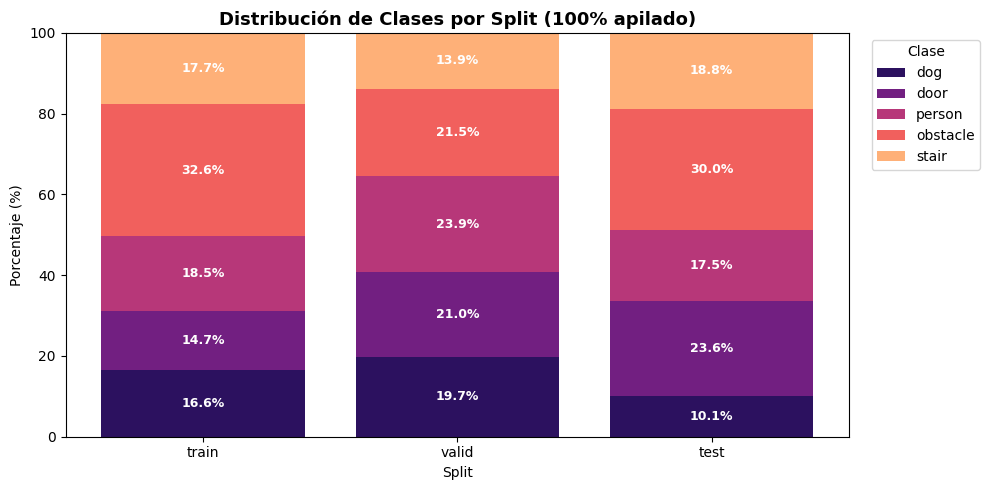

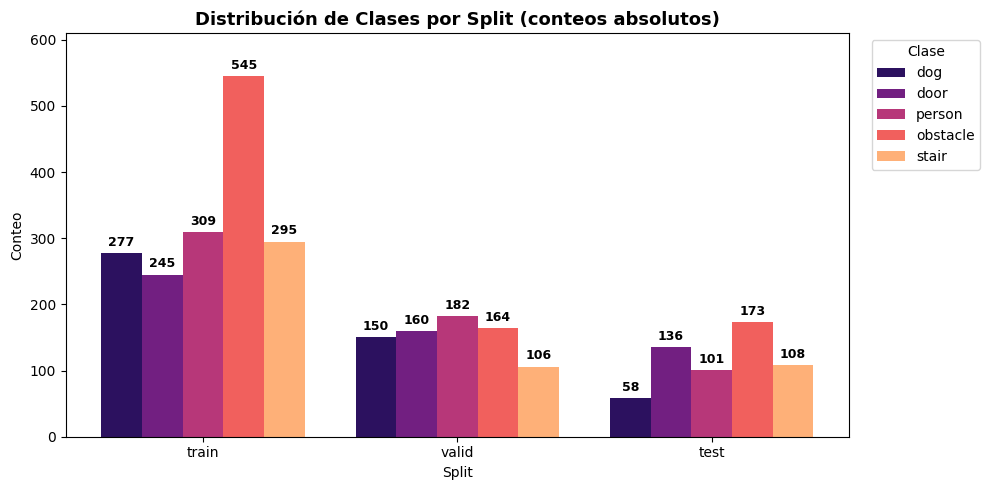

,split,dog,door,person,obstacle,stair,background,total_annotations,total_images
0,train,277,245,309,545,295,87,1671,874
1,valid,150,160,182,164,106,19,762,188
2,test,58,136,101,173,108,19,576,187


In [35]:
# Analizar distribución de clases por split (incluye background) y exportar tabla + figura
from utils_preprocessing import analyze_split_class_distribution

split_train_json = os.path.join(split_output_dir, "train", "_annotations.coco.json")
split_valid_json = os.path.join(split_output_dir, "valid", "_annotations.coco.json")
split_test_json = os.path.join(split_output_dir, "test", "_annotations.coco.json")

split_json_paths = {
    "train": split_train_json,
    "valid": split_valid_json,
    "test": split_test_json,
}

df_split_classes = analyze_split_class_distribution(
    split_json_paths=split_json_paths,
    class_names=["dog", "door", "person", "obstacle", "stair", "background"],
    palette="magma",
    figsize=(10, 5),
    title="Distribución de Clases por Split",
    output_dir=output_dir,
    filename="04_split_class_distribution",
    show_plot=True,
 )

display(df_split_classes)

---

## Paso 4: Análisis de la Distribución de Clases del Set Train

Analizar la distribución de clases del set train para detectar posibles desbalances y aplicar técnicas de augmentación si es necesario.

,Category,Count
0,obstacle,545
1,person,309
2,stair,295
3,dog,277
4,door,245


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/05_class_distribution_train.png


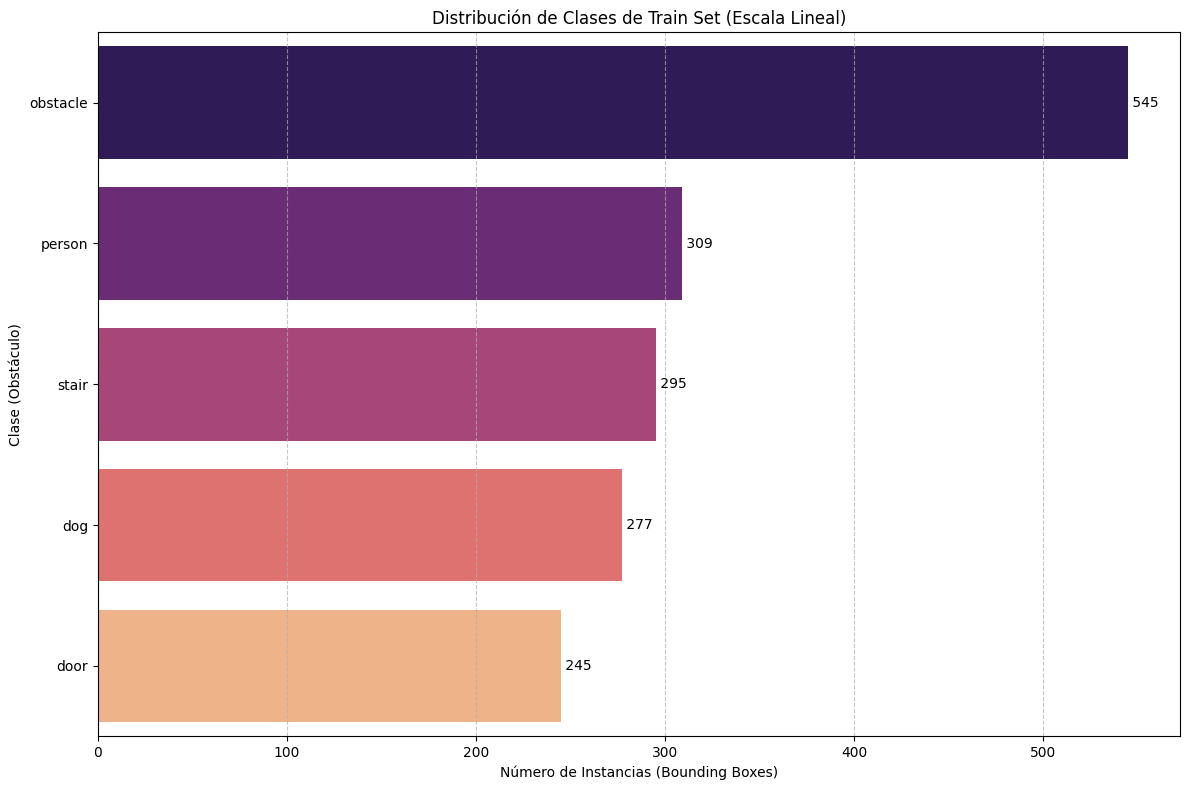


--- Tabla de Distribución ---
| Category   |   Count |
|:-----------|--------:|
| obstacle   |     545 |
| person     |     309 |
| stair      |     295 |
| dog        |     277 |
| door       |     245 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/05_class_distribution_train.csv


In [36]:
# Analizar la distribución de clases del set train para evaluar desbalance

# Filtrar solo Train
df_train = df_split_classes[df_split_classes['split'] == 'train'].copy()
if df_train.empty:
    raise ValueError("No se encontró la fila del split 'train' en df_split_classes")

# plot_category_distribution() espera columnas: Category, Count
exclude_cols = {'split', 'total_annotations', 'total_images', 'background'}
class_cols = [c for c in df_train.columns if c not in exclude_cols]

df_train_counts = (
    df_train[class_cols]
    .iloc[0]
    .rename_axis('Category')
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
    .reset_index(drop=True)
)

display(df_train_counts)

plot_category_distribution(
    df_counts=df_train_counts,
    scale_type='linear',
    palette='magma',
    output_dir=output_dir,
    filename='05_class_distribution_train',
    title='Distribución de Clases de Train Set (Escala Lineal)'
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


,Category,Images,Objects
0,dog,243,277
1,door,197,245
2,obstacle,386,545
3,person,283,309
4,stair,285,295


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/06_image_object_density_train.png


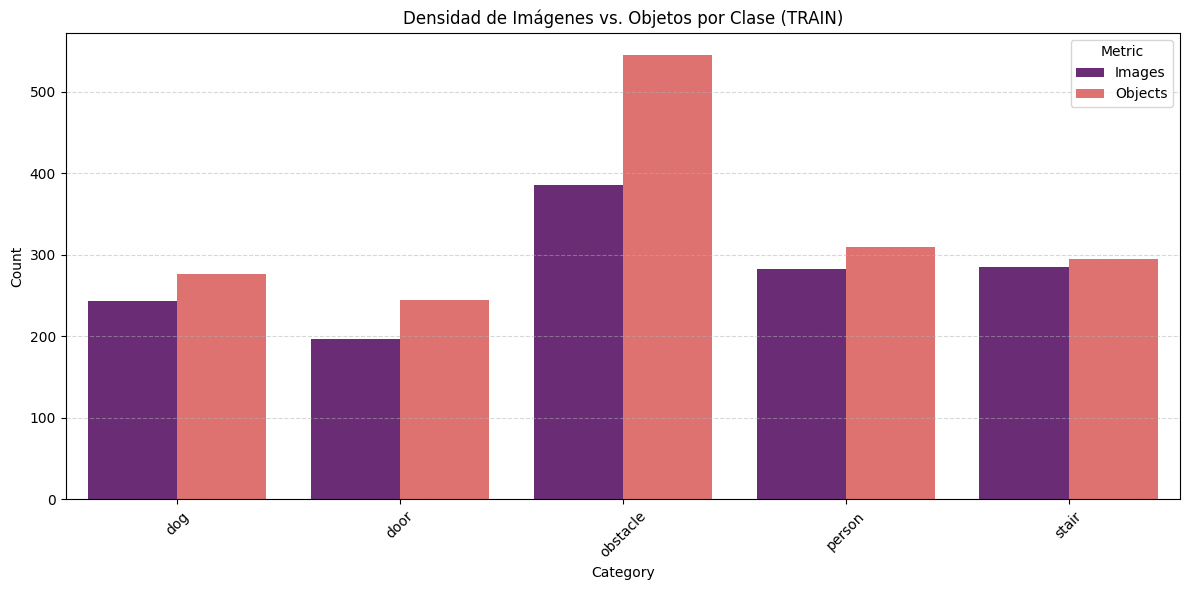

In [37]:
# Obtener la densidad Imágenes vs Objetos por clase para el split TRAIN

# Cargar explícitamente el JSON de train (evita mezclar con el dataset completo)
if not os.path.exists(split_train_json):
    raise FileNotFoundError(f"No se encontró el JSON de train: {split_train_json}")

coco_train = COCO(split_train_json)
cat_ids_train = coco_train.getCatIds()

# calculate_image_object_density(coco, cat_ids) -> (df_density, active_cat_ids)
df_density, active_cat_ids = calculate_image_object_density(coco_train, cat_ids_train)

display(df_density)

# plot_image_object_density(df_density, palette, figsize, output_dir, filename, title)
plot_image_object_density(
    df_density=df_density,
    palette='magma',
    figsize=(12, 6),
    output_dir=output_dir,
    filename='06_image_object_density_train',
    title='Densidad de Imágenes vs. Objetos por Clase (TRAIN)'
)


--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---
| Category   |   Images |   Objects |   Ratio |
|:-----------|---------:|----------:|--------:|
| obstacle   |      386 |       545 |  1.4119 |
| door       |      197 |       245 |  1.2437 |
| dog        |      243 |       277 |  1.1399 |
| person     |      283 |       309 |  1.0919 |
| stair      |      285 |       295 |  1.0351 |
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/07_density_ratio.png
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/07_density_ratio.csv


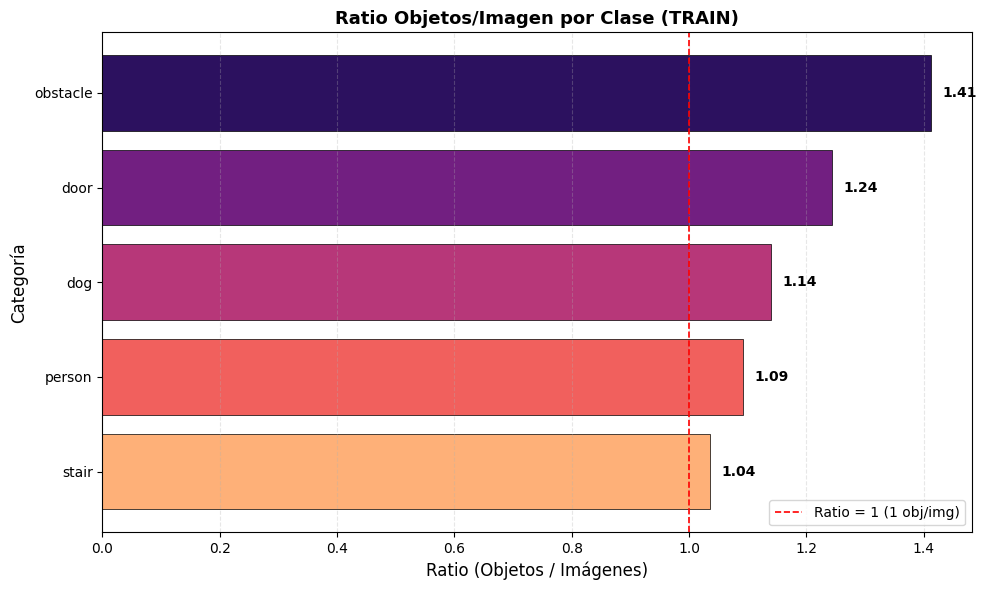

In [38]:
# Calcular ratio Objetos/Imagen por categoría
df_ratio = calculate_and_plot_density_ratio(
    df_density, 
    palette='magma',
    output_dir=output_dir, 
    filename='07_density_ratio', 
    title='Ratio Objetos/Imagen por Clase (TRAIN)'
)

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/08_cooccurrence_matrix.png
💾 Matriz guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/08_cooccurrence_matrix.csv


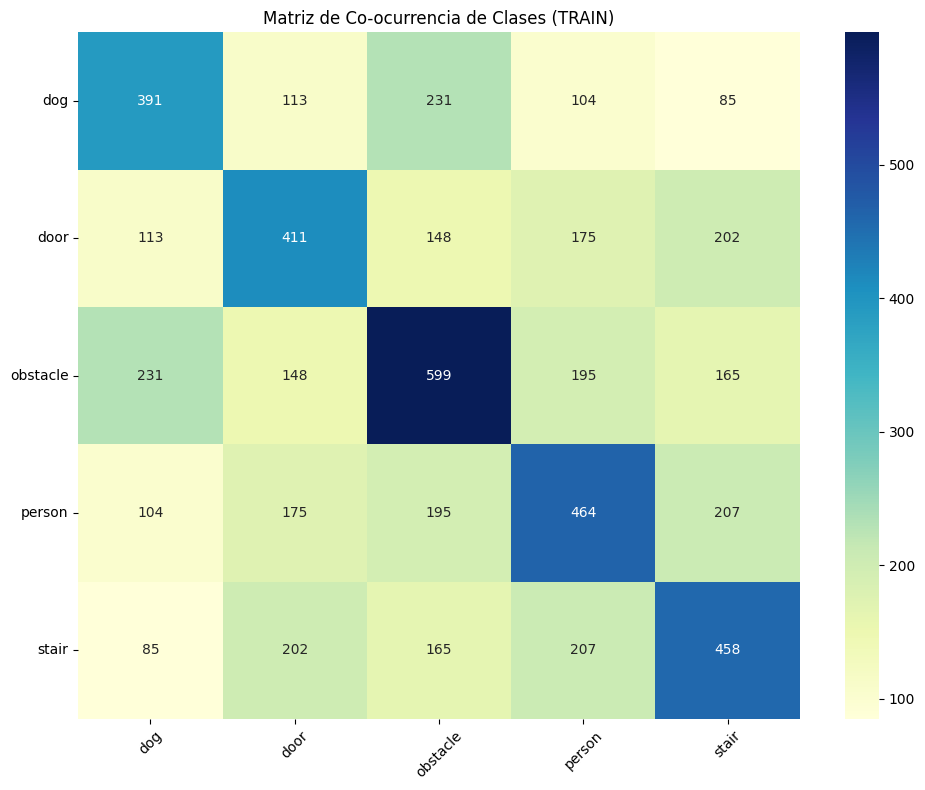

In [39]:
# Obtener Matriz de Co-ocurrencia
co_occurrence_matrix, cat_labels = calculate_cooccurrence_matrix(coco, active_cat_ids)
plot_cooccurrence_matrix(
    co_occurrence_matrix, 
    cat_labels, 
    cmap='YlGnBu',
    output_dir=output_dir, 
    filename='08_cooccurrence_matrix', 
    title='Matriz de Co-ocurrencia de Clases (TRAIN)'
)

---

## Paso 5: Data Augmentation


Con base en los gráficos previos del análisis del Train Set (874 imágenes y 1,671 anotaciones), donde se observa que la clase `obstacle` (545) duplica en frecuencia a `door` (245) y supera significativamente a `dog` (277), `stair` (295) y `person` (309), procedemos a estructurar el plan final de aumentación. Se plantea el siguiente plan de aumentación para mitigar este desbalance:

Para un robot LCMR con hardware limitado (ESP32-S3), el balanceo no es solo una cuestión estadística, sino de seguridad operativa:

* **Navegación Semántica y Crítica:** Las clases `door` (transición) y `stair` (límite/riesgo) son estructuralmente más importantes que un `obstacle` genérico. Un sesgo hacia `obstacle` podría causar que el robot intente atravesar una "puerta" o ignore el peligro de una "escalera" al clasificarlos erróneamente como objetos estáticos simples.

* **Seguridad Biológica:** Las clases `person` y `dog` requieren un Recall extremadamente alto. Dado que el modelo se cuantizará a INT8, el margen de error se reduce; un dataset equilibrado asegura que los pesos de la red no se saturen con características de muebles, permitiendo una discriminación fina de agentes móviles.

* **Compensación de Ratios:** El ratio de objetos por imagen es bajo (1.04 a 1.24 para las clases débiles). Esto significa que el modelo ve pocos ejemplos por captura; el balanceo offline compensará esta baja densidad de información por frame.






1. **Matriz de Aumentación Offline (Fase de Balanceo)**

Esta fase se ejecuta antes del entrenamiento para igualar el volumen de las clases al nivel de `obstacle`.

| Clase | Target de Aumento | Técnicas Específicas | Lógica de Programación y Configuración |
| :--- | :--- | :--- | :--- |
| **dog** | +97% (de 277 a 545) | Horizontal Flip + Gaussian Noise | Aplicar flip y añadir ruido ($\sigma=0.02$) para emular sensor OV5640 en noche. |
| **door** | +122% (de 245 a 545) | Horizontal Flip + Perspective Warp | Invertir $x$ y aplicar skew leve ($\pm 5\%$) para simular aproximación diagonal del robot. |
| **stair** | +85% (de 295 a 545) | Horizontal Flip + Crop/Zoom | Invertir $x$ y hacer zoom ($1.1x$) para simular que el robot está más cerca del límite estructural. |
| **person** | +76% (de 309 a 545) | Horizontal Flip + Blur/Sharpen | Invertir $x$ y aplicar desenfoque leve para simular movimiento relativo persona-robot. |

2. **Matriz de Aumentación Online (Fase de Generalización)**

Estas transformaciones ocurren en cada epoch para que el modelo no memorice el dataset balanceado, se detallan acá para tenerlas en cuenta pero se desarrollarán en la sección de entrenamiento del proyecto. 

| Técnica | Configuración Sugerida | Qué Asegurar / Lógica |
| :--- | :--- | :--- |
| **Mosaic (4-img)** | Probabilidad: $1.0$ (100%) | **Asegurar:** Obliga a detectar objetos en miniatura. Vital para la pérdida de resolución a $192 \times 192$. |
| **HSV-Hue** | $h=0.015, s=0.7, v=0.4$ | **Lógica:** Variar tono, saturación y valor. **Asegurar:** No cambiar el color natural (ej. que un perro no sea azul). |
| **Degrees (Rot)** | $\pm 10.0^\circ$ | **Lógica:** Rotaciones aleatorias. **Asegurar:** El robot opera en suelos; rotaciones mayores son irreales. |
| **Multiscale** | Rango: $320$ a $640$ px | **Lógica:** Cambiar resolución cada 10 batches. **Asegurar:** Robustez ante múltiplos inferiores de resoluciones de 640px|

3. **Salvaguardas y control de errores**

Para garantizar que la implementación sea exitosa, se debe evitar estos fallos comunes:

| Posible Fallo / Categoría | Descripción del Error | Acción o Restricción Crítica |
| :--- | :--- | :--- |
| **Inversión de Coordenadas (Flip)** | El BBox queda en el lado opuesto al objeto real si no se recalcula el centro. | **Lógica:** La nueva coordenada $x_{center}$ debe ser $1.0 - x_{old\_center}$. |
| **Prohibición de Vertical Flip** | Invertir el eje $Y$ destruye la percepción del plano de tierra del robot. | **Restricción:** Bajo ninguna circunstancia invertir el eje $Y$; los obstáculos deben permanecer en el suelo. |
| **Ajuste "Tight" (BBox)** | En *Crop* o *Perspective*, el cuadro se aleja de los bordes del objeto. | **Asegurar:** El BBox debe seguir tocando los bordes (anotación modal) para no perder precisión en el ESP32-S3. |
| **Cascada en Co-ocurrencia** | Aumentar una clase (ej. *dog*) afecta involuntariamente a otra presente (ej. *obstacle*). | **Script:** Implementar un contador en tiempo real que detenga el aumento al alcanzar el target (545) de la clase objetivo. |

In [42]:
# Ejecución de la Aumentación Offline (solo TRAIN)
dataset_split_dir = os.path.join(
    base_dir,
    "Datasets",
    "dataset_IODC_original_3",
    "dataset_split",
)

offline_aug_output_dir = os.path.join(
    dataset_split_dir,
    "train_augmented_offline_v1",
)

# Matriz de políticas offline definida en la celda 26
offline_policies = build_default_offline_balance_policies(target_count=545)

# Control de cascada por co-ocurrencia (tope con tolerancia)
cascade_cfg = CascadeControlConfig(
    enabled=True,
    collateral_tolerance_ratio=0.03,
    target_overshoot_tolerance=2,
    enforce_for_all_classes=True,
)

run_cfg = OfflineAugRunConfig(
    seed=42,
    min_bbox_area=4.0,
    min_visibility=0.20,
    max_generated_images=20000,
    output_json_name="_annotations.coco.json",
    output_images_subdir="images",
    verbose=True,
)

summary_offline_aug = augment_dataset_split_train_offline(
    dataset_split_dir=dataset_split_dir,
    output_dir=offline_aug_output_dir,
    policies=offline_policies,
    cascade_cfg=cascade_cfg,
    run_cfg=run_cfg,
)

print("\n📌 Resumen general")
print(f"Output dir: {summary_offline_aug['output_dir']}")
print(f"JSON salida: {summary_offline_aug['output_json_path']}")
print(f"Imágenes generadas: {summary_offline_aug['generated_images']}")

print("\n📊 Reporte de targets")
display(pd.DataFrame(summary_offline_aug["target_report"]))

if summary_offline_aug.get("rejection_reasons"):
    print("\n⚠️ Rechazos por reglas de control")
    display(
        pd.DataFrame(
            [
                {"reason": k, "count": v}
                for k, v in summary_offline_aug["rejection_reasons"].items()
            ]
        ).sort_values("count", ascending=False)
    )

📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1
📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1/images

🚀 Iniciando augmentación offline balanceada (TRAIN)
   📄 JSON train: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train/_annotations.coco.json
   🖼️  Imágenes train: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train/images
   📦 Output: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1
   🎯 Targets:
      - dog: 277 -> 545
      - door: 245 -> 545
      - stair: 295 -> 545
      - person: 309 -> 545

✅ Augmentación offline completada
   dog: 277 -> 545 (target=545, OK)
   door: 245 -> 545 (target=545, OK)
   stair: 295 -> 548 (target=545, OK)


,class_id,class_name,before,after,delta,target,target_hit
0,0,dog,277,545,268,545,True
1,1,door,245,545,300,545,True
2,4,stair,295,548,253,545,True
3,3,person,309,545,236,545,True



⚠️ Rechazos por reglas de control


,reason,count
0,collateral_cap_exceeded:2,166


In [45]:
# Setup de comparación TRAIN before vs after (offline augmentation)
train_before_json = os.path.join(dataset_split_dir, "train", "_annotations.coco.json")
train_before_images_dir = os.path.join(dataset_split_dir, "train", "images")

train_after_json = os.path.join(offline_aug_output_dir, "_annotations.coco.json")
train_after_images_dir = os.path.join(offline_aug_output_dir, "images")

compare_output_dir = os.path.join(
    output_dir,
    "09_before_after_train_offline_v1",
)
ensure_dir(compare_output_dir)

print("📁 Rutas de trabajo")
print(f"- TRAIN before json: {train_before_json}")
print(f"- TRAIN before images: {train_before_images_dir}")
print(f"- TRAIN after json: {train_after_json}")
print(f"- TRAIN after images: {train_after_images_dir}")
print(f"- Output comparación: {compare_output_dir}")

compare_ctx = load_train_before_after_coco(
    before_json_path=train_before_json,
    after_json_path=train_after_json,
)

print("\n📌 Resumen before/after")
display(compare_ctx["summary_df"])

# Integridad estructural before y after
integrity_before = validate_coco_annotation_integrity(
    coco_json_path=train_before_json,
    images_dir=train_before_images_dir,
    min_bbox_area=4.0,
    check_image_readability=True,
)

integrity_after = validate_coco_annotation_integrity(
    coco_json_path=train_after_json,
    images_dir=train_after_images_dir,
    min_bbox_area=4.0,
    check_image_readability=True,
)

print("\n🧪 Integridad BEFORE")
print(f"Status: {integrity_before['status']} | errores críticos: {integrity_before['critical_errors']} | total: {integrity_before['total_errors']}")
display(integrity_before["report_df"])

print("\n🧪 Integridad AFTER")
print(f"Status: {integrity_after['status']} | errores críticos: {integrity_after['critical_errors']} | total: {integrity_after['total_errors']}")
display(integrity_after["report_df"])

📁 Rutas de trabajo
- TRAIN before json: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train/_annotations.coco.json
- TRAIN before images: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train/images
- TRAIN after json: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1/_annotations.coco.json
- TRAIN after images: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1/images
- Output comparación: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

📌 Resumen before/after


,version,num_images,num_annotations,num_categories
0,before,874,1671,5
1,after,1470,2744,5



🧪 Integridad BEFORE
Status: PASS | errores críticos: 0 | total: 0


,check,count
0,duplicate_image_ids,0
1,duplicate_annotation_ids,0
2,missing_image_files,0
3,unreadable_images,0
4,invalid_annotation_image_ref,0
5,invalid_annotation_category_ref,0
6,invalid_bbox_format,0
7,invalid_bbox_size,0
8,bbox_out_of_bounds,0
9,bbox_area_mismatch,0



🧪 Integridad AFTER
Status: PASS | errores críticos: 0 | total: 0


,check,count
0,duplicate_image_ids,0
1,duplicate_annotation_ids,0
2,missing_image_files,0
3,unreadable_images,0
4,invalid_annotation_image_ref,0
5,invalid_annotation_category_ref,0
6,invalid_bbox_format,0
7,invalid_bbox_size,0
8,bbox_out_of_bounds,0
9,bbox_area_mismatch,0


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_01_class_distribution_before.png


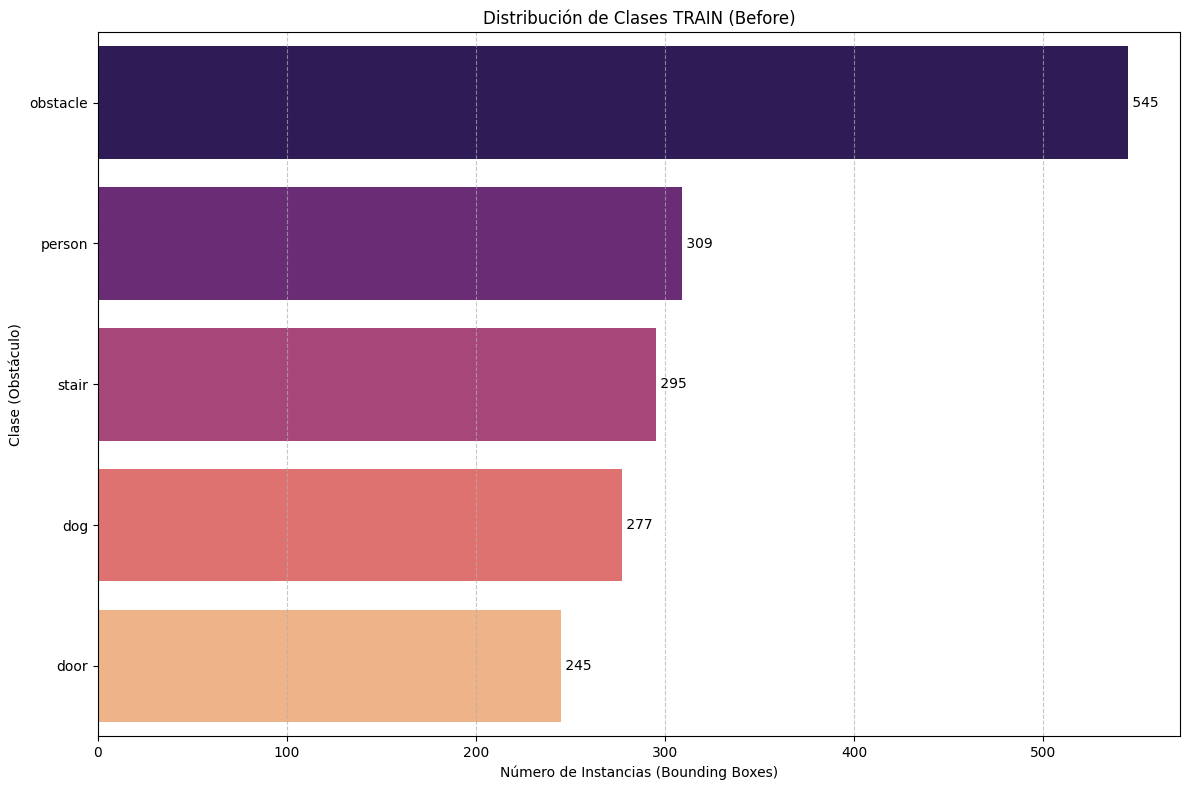


--- Tabla de Distribución ---
| Category   |   Count |
|:-----------|--------:|
| obstacle   |     545 |
| person     |     309 |
| stair      |     295 |
| dog        |     277 |
| door       |     245 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_01_class_distribution_before.csv
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_02_class_distribution_after.png


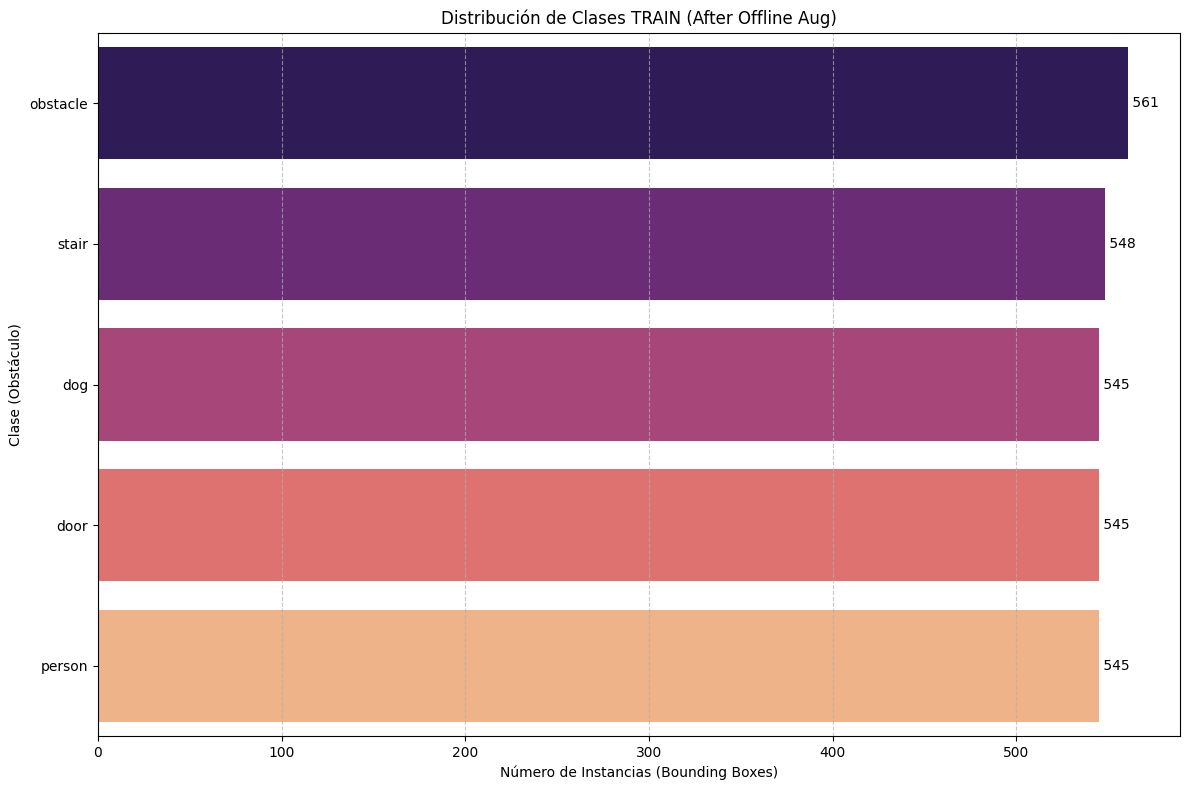


--- Tabla de Distribución ---
| Category   |   Count |
|:-----------|--------:|
| obstacle   |     561 |
| stair      |     548 |
| dog        |     545 |
| door       |     545 |
| person     |     545 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_02_class_distribution_after.csv
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_03_density_before.png


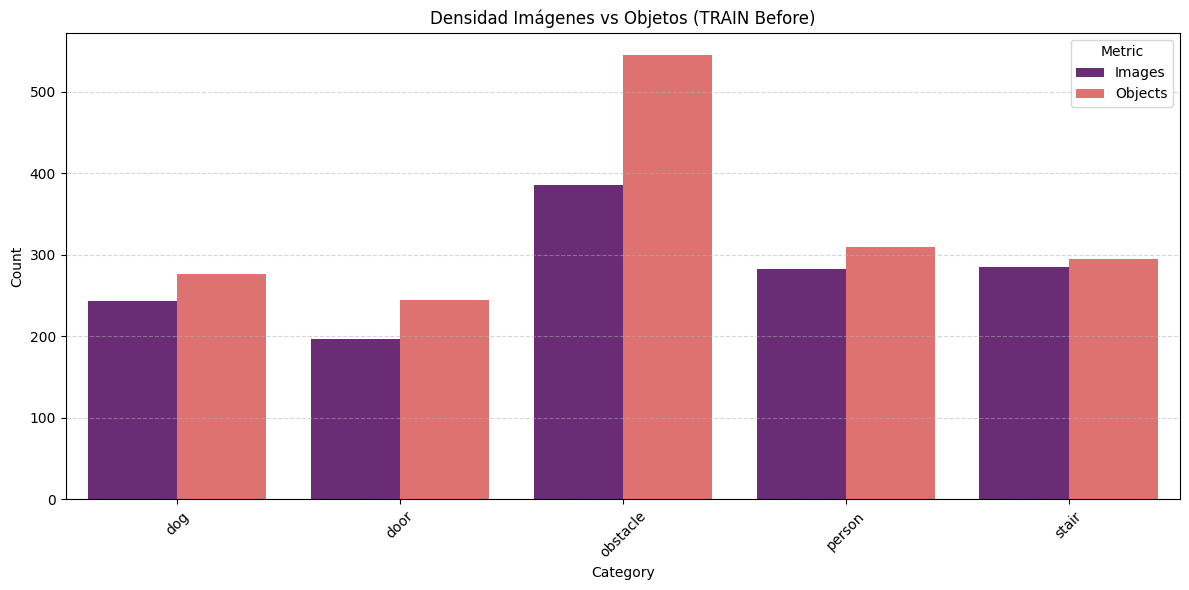

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_04_density_after.png


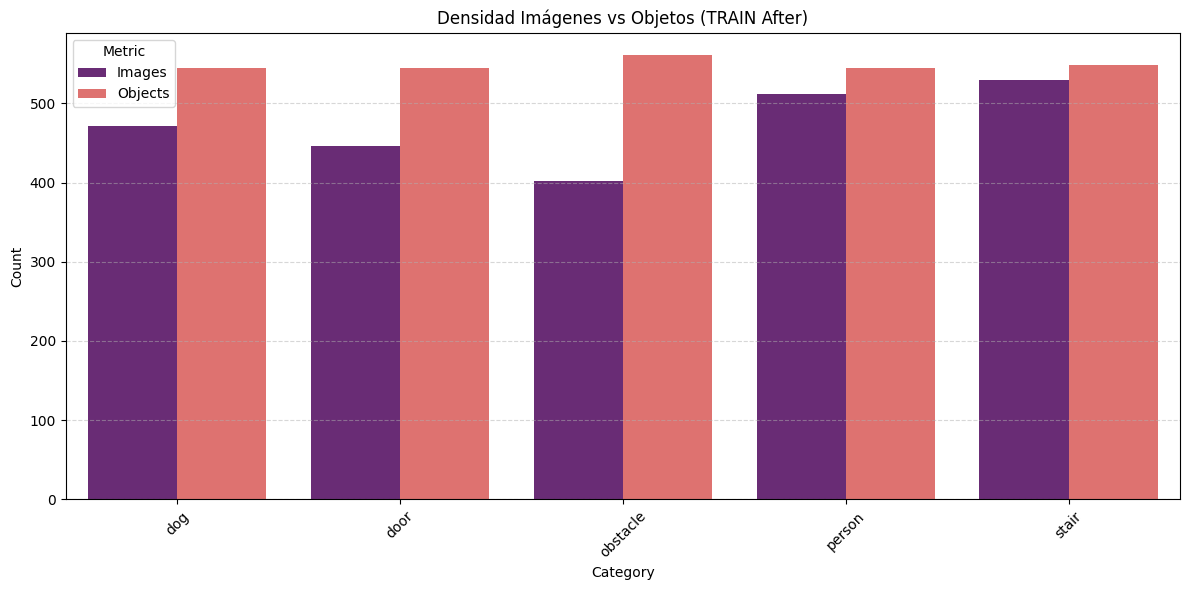


--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---
| Category   |   Images |   Objects |   Ratio |
|:-----------|---------:|----------:|--------:|
| obstacle   |      386 |       545 |  1.4119 |
| door       |      197 |       245 |  1.2437 |
| dog        |      243 |       277 |  1.1399 |
| person     |      283 |       309 |  1.0919 |
| stair      |      285 |       295 |  1.0351 |
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_05_ratio_before.png
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_05_ratio_before.csv


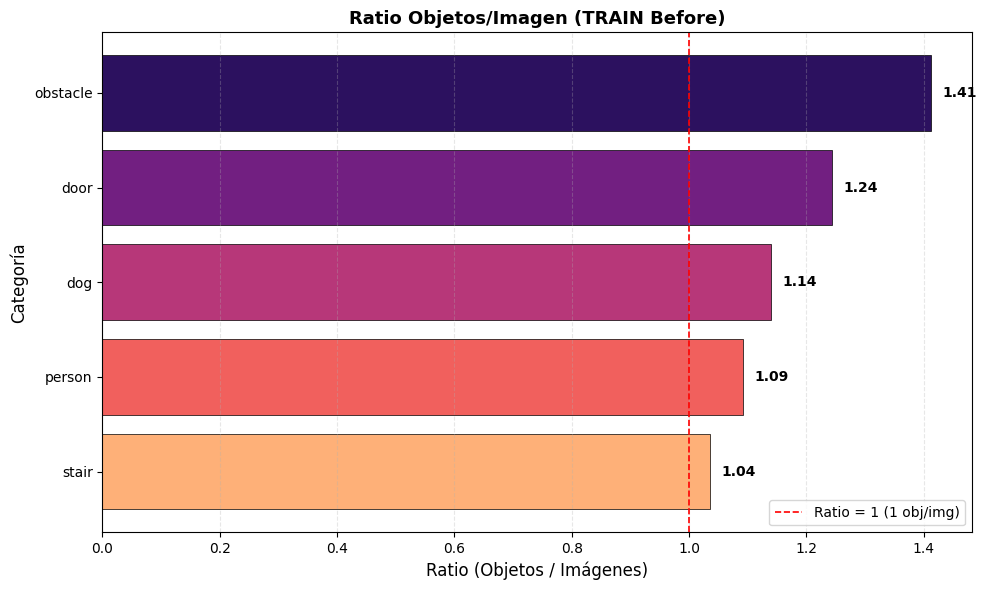


--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---
| Category   |   Images |   Objects |   Ratio |
|:-----------|---------:|----------:|--------:|
| obstacle   |      402 |       561 |  1.3955 |
| door       |      446 |       545 |  1.222  |
| dog        |      472 |       545 |  1.1547 |
| person     |      512 |       545 |  1.0645 |
| stair      |      530 |       548 |  1.034  |
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_06_ratio_after.png
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_06_ratio_after.csv


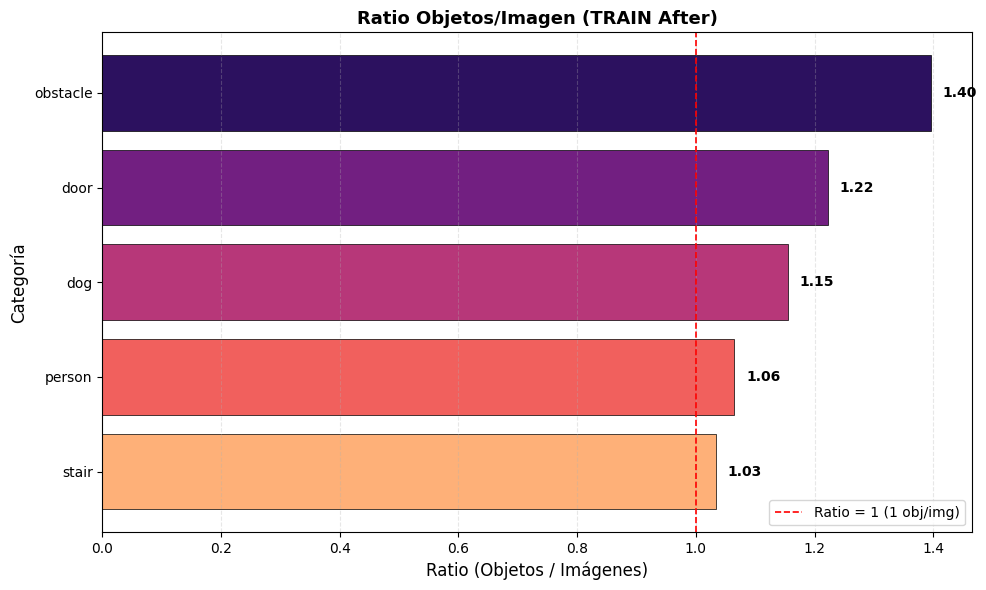

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_07_cooccurrence_before.png
💾 Matriz guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_07_cooccurrence_before.csv


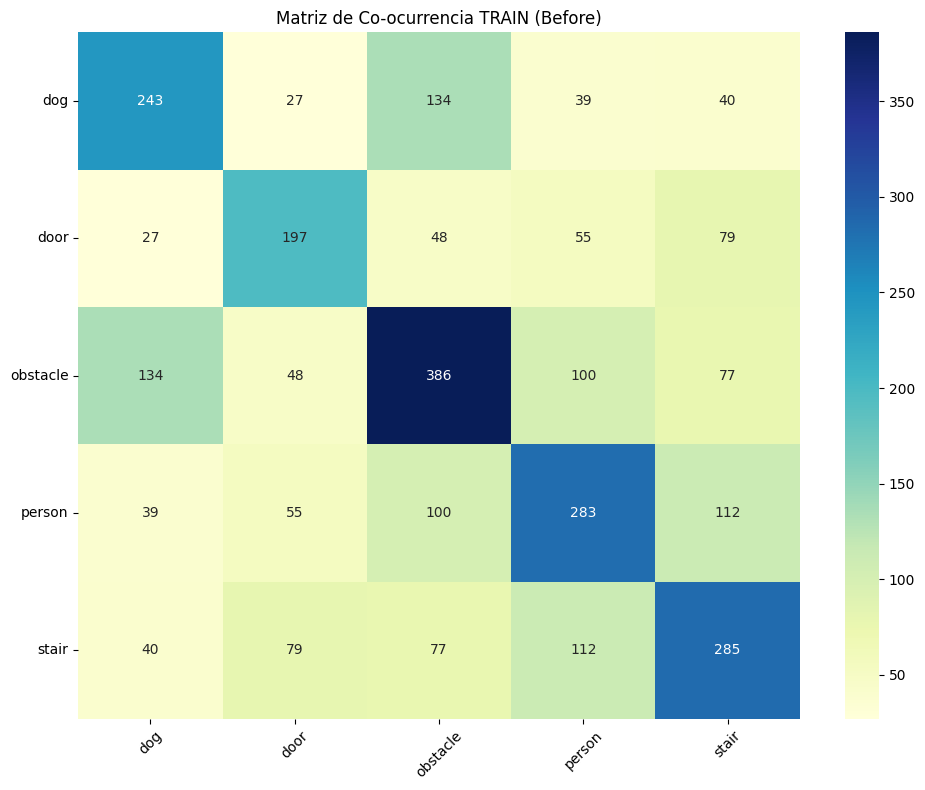

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_08_cooccurrence_after.png
💾 Matriz guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ref_08_cooccurrence_after.csv


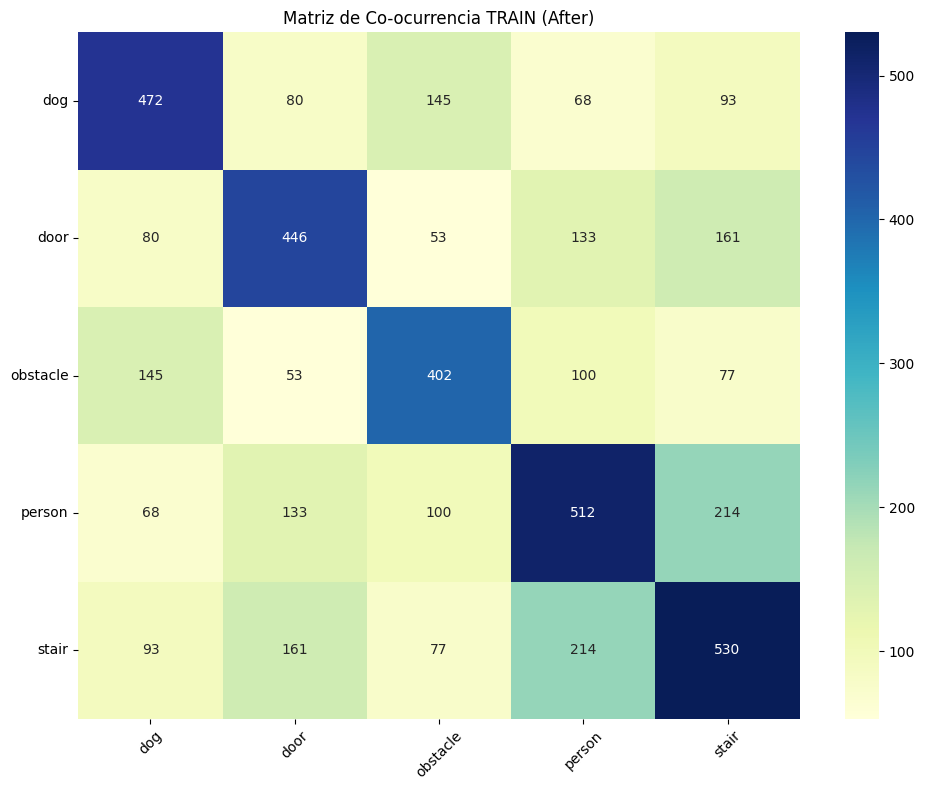


📊 Delta distribución de clases (before -> after)


,Category,Count_before,Count_after,Delta
1,door,245,545,300
0,dog,277,545,268
4,stair,295,548,253
3,person,309,545,236
2,obstacle,545,561,16



📊 Delta densidad imágenes/objetos


,Category,Images_before,Objects_before,Images_after,Objects_after,Delta_images,Delta_objects
1,door,197,245,446,545,249,300
0,dog,243,277,472,545,229,268
4,stair,285,295,530,548,245,253
3,person,283,309,512,545,229,236
2,obstacle,386,545,402,561,16,16



📊 Delta ratio objetos/imagen


,Category,Ratio_before,Ratio_after,Delta_ratio
0,dog,1.1399,1.1547,0.0148
4,stair,1.0351,1.0340,-0.0011
2,obstacle,1.4119,1.3955,-0.0164
1,door,1.2437,1.2220,-0.0217
3,person,1.0919,1.0645,-0.0274



📊 Delta matriz de co-ocurrencia (after - before)


,dog,door,obstacle,person,stair
dog,229.0,53.0,11.0,29.0,53.0
door,53.0,249.0,5.0,78.0,82.0
obstacle,11.0,5.0,16.0,0.0,0.0
person,29.0,78.0,0.0,229.0,102.0
stair,53.0,82.0,0.0,102.0,245.0


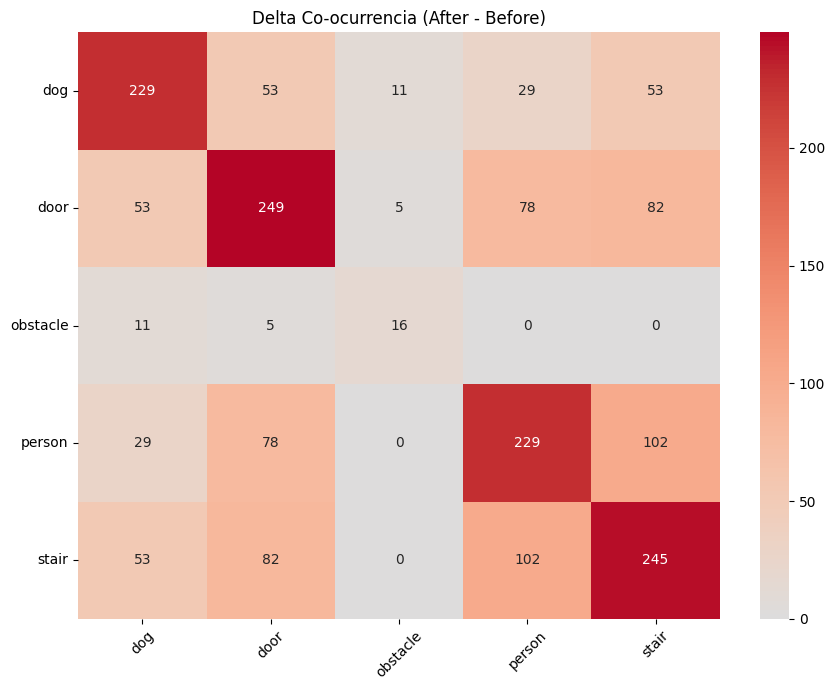


📐 Geometría de Bounding Boxes extraída: 1671 anotaciones
| Category   |   Count |   Area_mean |   Area_median |   Ratio_mean |   Ratio_std |
|:-----------|--------:|------------:|--------------:|-------------:|------------:|
| dog        |     277 |     50702.4 |       39210.3 |         1.1  |        0.48 |
| door       |     245 |     75205.1 |       73244.2 |         0.47 |        0.21 |
| obstacle   |     545 |     55773.4 |       47837.1 |         0.75 |        0.38 |
| person     |     309 |     67607.5 |       55410.4 |         0.52 |        0.24 |
| stair      |     295 |     64020.4 |       57315.6 |         1.28 |        0.59 |
💾 Geometría guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_01_geo_before.csv
💾 Resumen guardado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_01_g

<Figure size 1000x600 with 0 Axes>

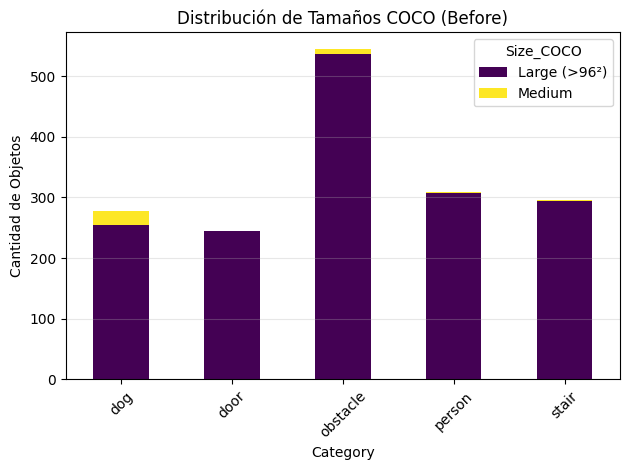


--- Porcentaje de Tamaños por Clase ---
| Category   |   Large (>96²) |   Medium |
|:-----------|---------------:|---------:|
| dog        |          91.7  |     8.3  |
| door       |         100    |     0    |
| obstacle   |          98.35 |     1.65 |
| person     |          99.68 |     0.32 |
| stair      |          99.66 |     0.34 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_03_size_before_percentages.csv
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_04_size_after.png


<Figure size 1000x600 with 0 Axes>

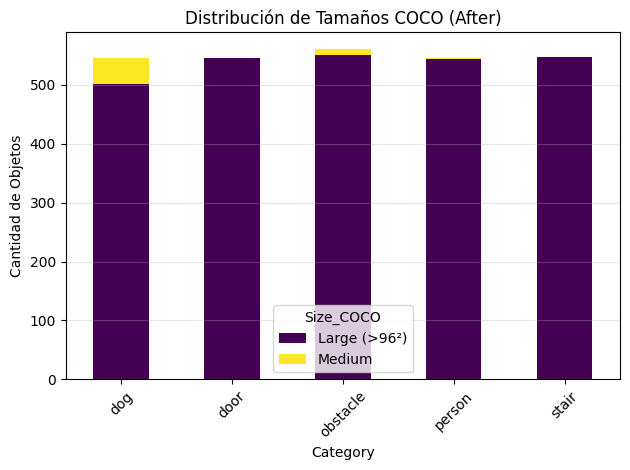


--- Porcentaje de Tamaños por Clase ---
| Category   |   Large (>96²) |   Medium |
|:-----------|---------------:|---------:|
| dog        |          91.93 |     8.07 |
| door       |         100    |     0    |
| obstacle   |          98.22 |     1.78 |
| person     |          99.63 |     0.37 |
| stair      |          99.82 |     0.18 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_04_size_after_percentages.csv


/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_eda.py:1018: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_geo, x='Category', y='Ratio', palette=palette)


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_05_aspect_before.png


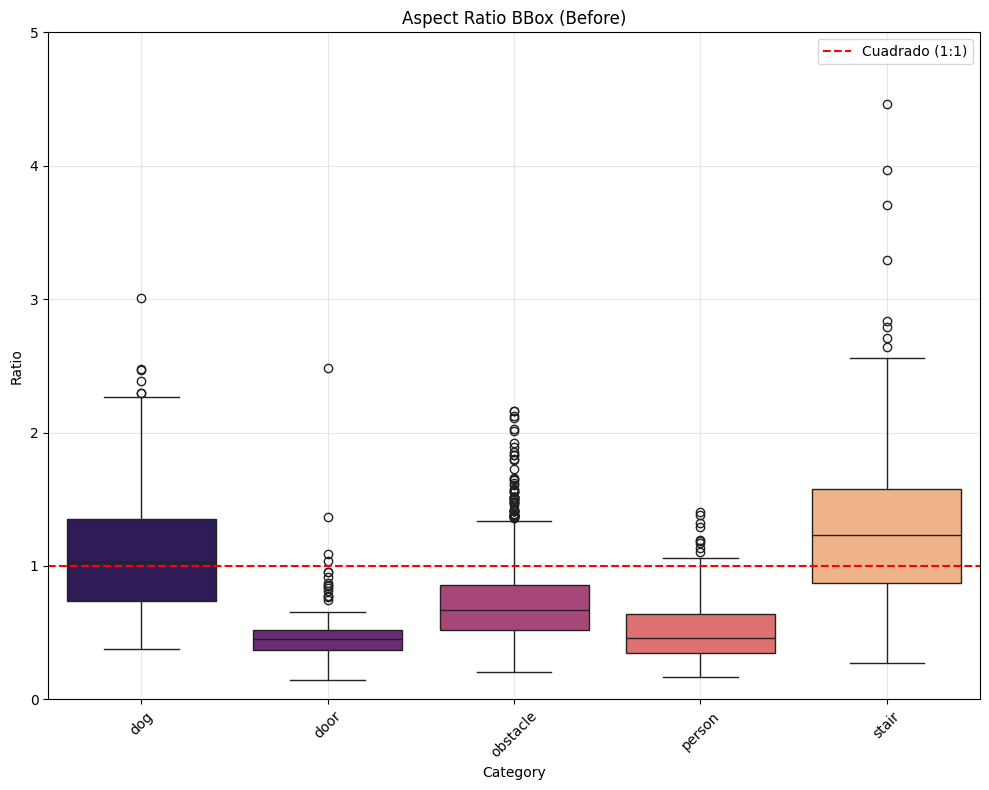

/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_eda.py:1018: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_geo, x='Category', y='Ratio', palette=palette)


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_06_aspect_after.png


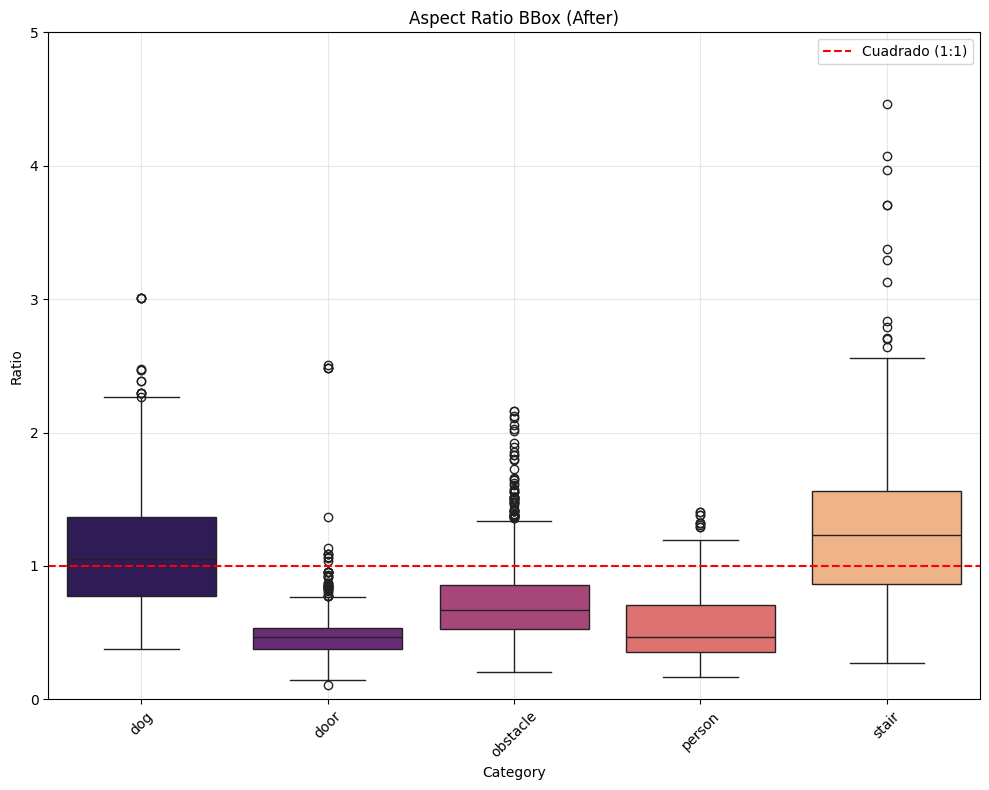

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_07_spatial_before.png


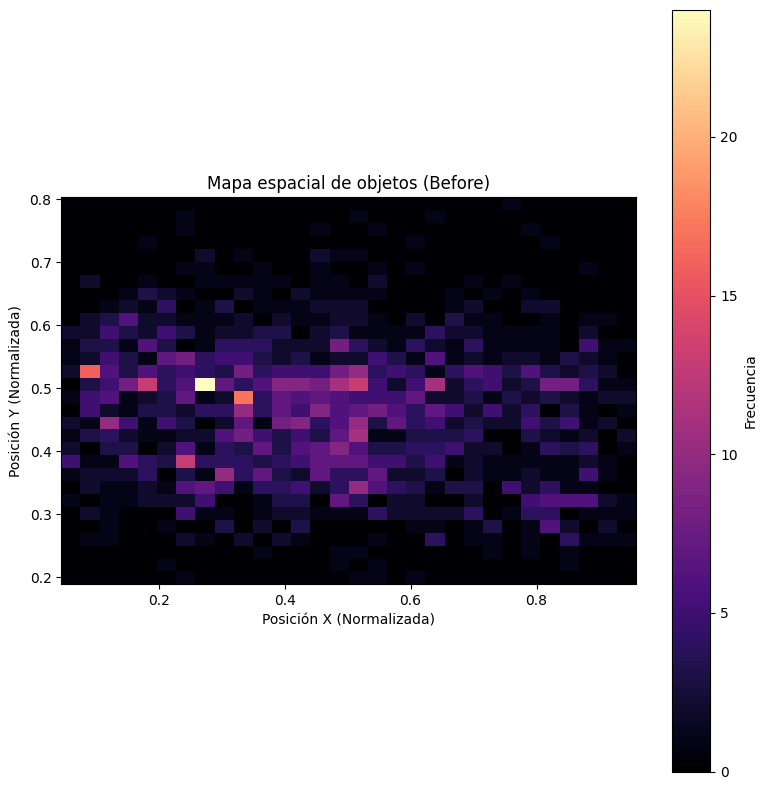

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_08_spatial_after.png


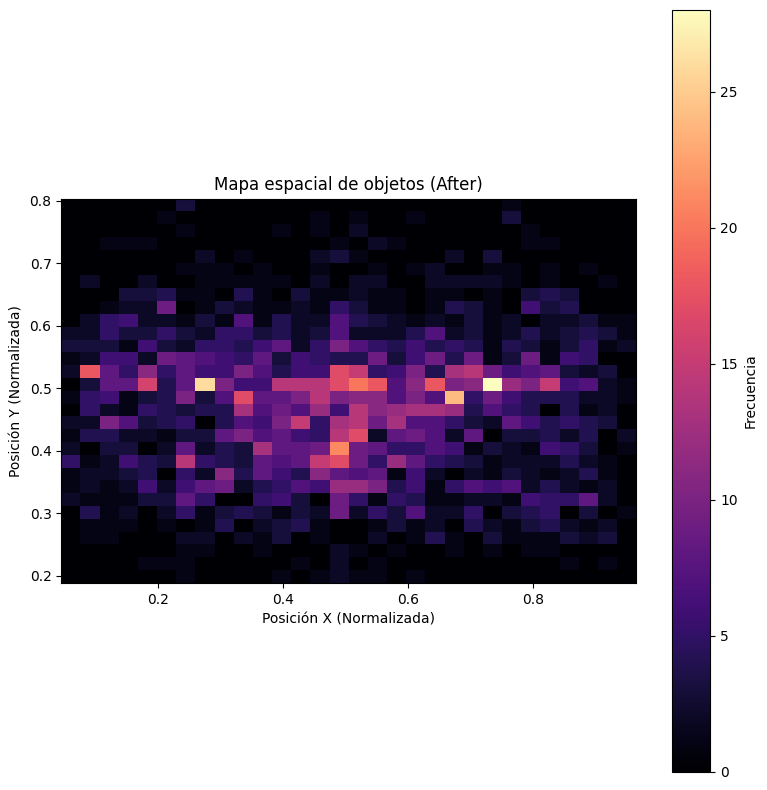

Procesando imágenes para calcular IoU y Densidad...
Procesando imágenes para calcular IoU y Densidad...
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_09_density_hist_before.png


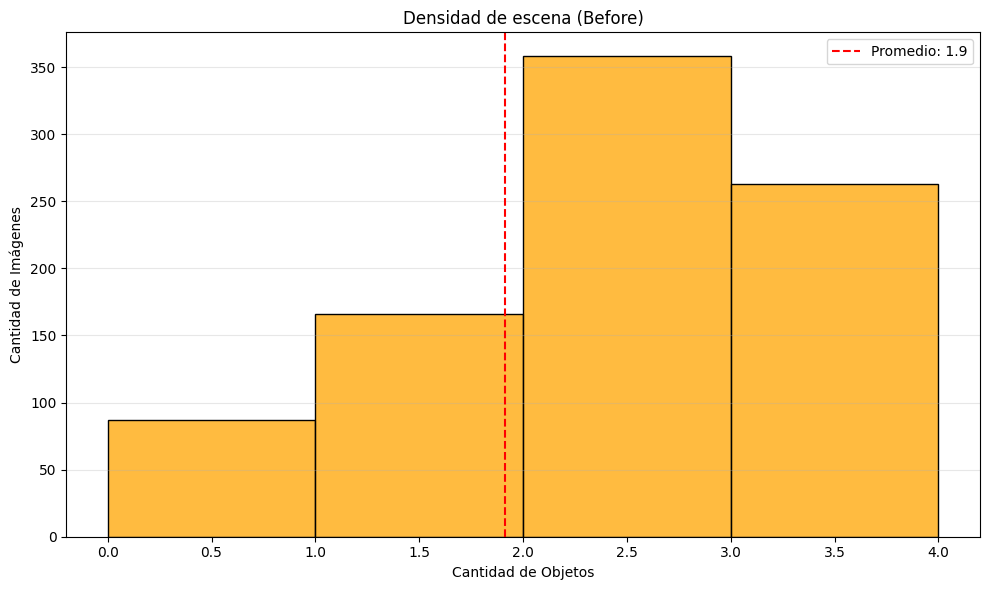

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_10_density_hist_after.png


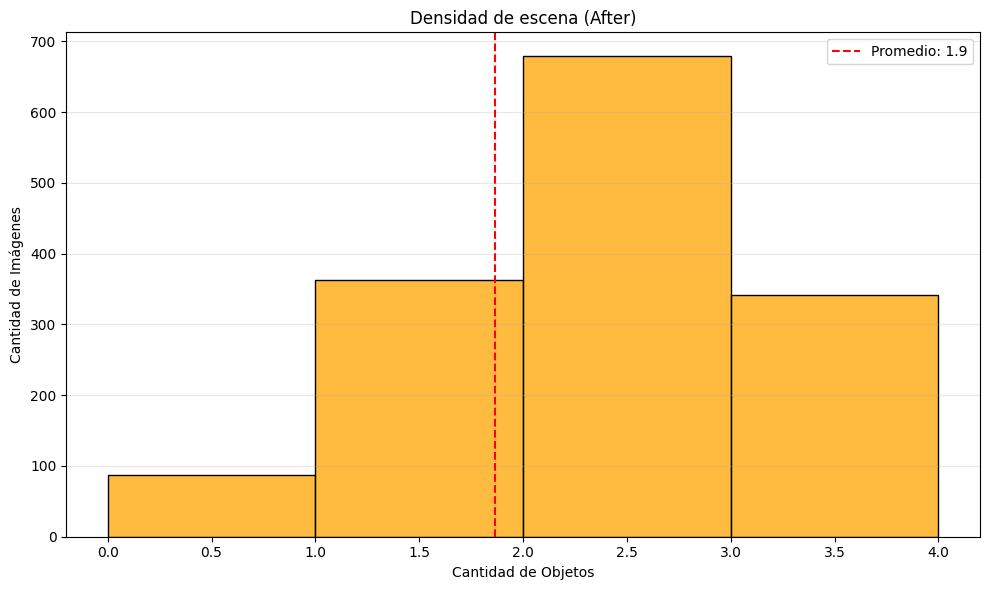

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_11_iou_hist_before.png


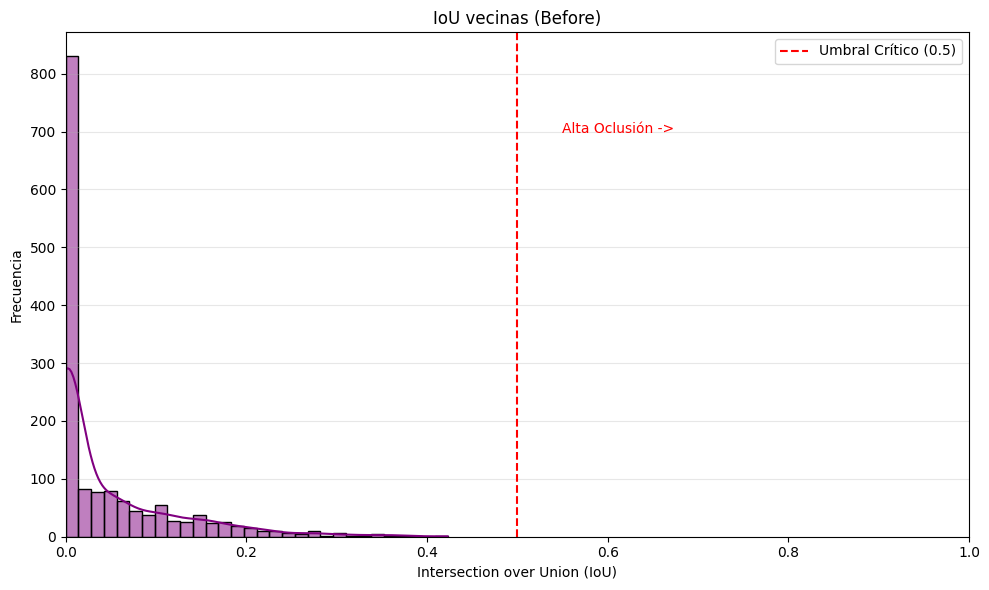

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/Process_Dataset_OIDC_original_v2/09_before_after_train_offline_v1/09_before_after_train_ext_12_iou_hist_after.png


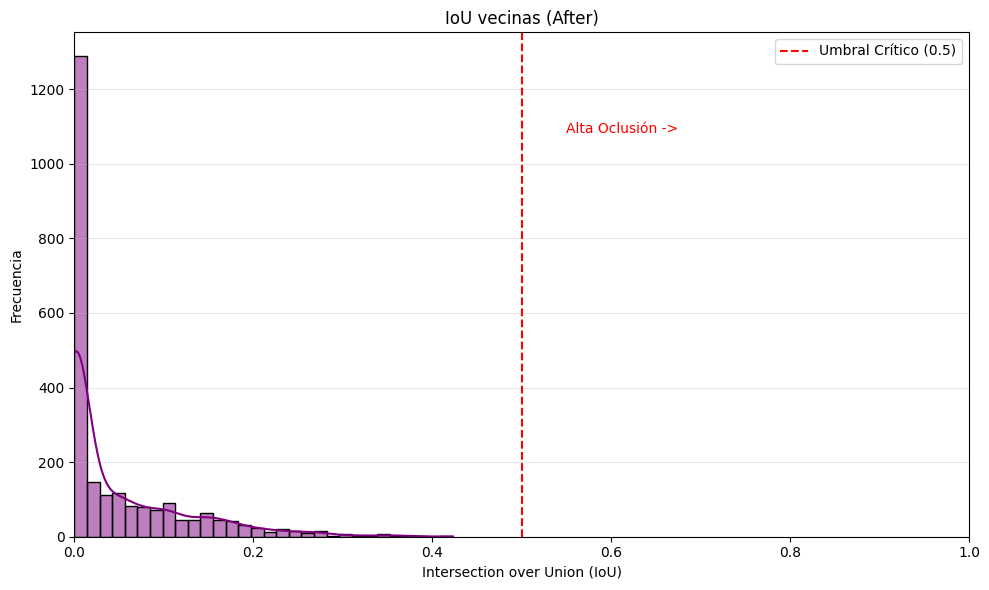


🧩 Resumen de métricas adicionales


,metric,before,after,delta
0,mean_objects_per_image,1.911899,1.866667,-0.045233
1,median_objects_per_image,2.000000,2.000000,0.000000
2,mean_iou_neighbors,0.047228,0.048148,0.000920



📝 Nota metodológica
Además de distribución/densidad/ratio/co-ocurrencia, se compararon: geometría de bboxes, mapas espaciales y complejidad de escena (densidad+IoU).

🆕 Imágenes detectadas como nuevas
- Por file_name diff: 596
- Por image_id diff: 596
- Por token '__aug_': 596
- Total combinado: 596


In [46]:
# Comparación before vs after con las 4 métricas base (celdas 20-23) + métricas adicionales
if "compare_ctx" not in globals():
    raise RuntimeError("Ejecuta primero la celda de setup before/after.")

results_ref = compare_train_before_after_reference_metrics(
    coco_before=compare_ctx["coco_before"],
    coco_after=compare_ctx["coco_after"],
    output_dir=compare_output_dir,
    prefix="09_before_after_train_ref",
    palette="magma",
)

print("\n📊 Delta distribución de clases (before -> after)")
display(results_ref["class_compare"].sort_values("Delta", ascending=False))

print("\n📊 Delta densidad imágenes/objetos")
display(results_ref["density_compare"].sort_values("Delta_objects", ascending=False))

print("\n📊 Delta ratio objetos/imagen")
display(results_ref["ratio_compare"].sort_values("Delta_ratio", ascending=False))

print("\n📊 Delta matriz de co-ocurrencia (after - before)")
display(results_ref["cooccurrence_delta"])

# Heatmap de delta de co-ocurrencia para inspección del efecto cascada
plt.figure(figsize=(9, 7))
sns.heatmap(
    results_ref["cooccurrence_delta"],
    annot=True,
    fmt=".0f",
    cmap="coolwarm",
    center=0,
)
plt.title("Delta Co-ocurrencia (After - Before)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Métricas adicionales (beyond celdas 20-23)
results_ext = compare_train_before_after_additional_metrics(
    coco_before=compare_ctx["coco_before"],
    coco_after=compare_ctx["coco_after"],
    output_dir=compare_output_dir,
    prefix="09_before_after_train_ext",
)

print("\n🧩 Resumen de métricas adicionales")
display(results_ext["summary_df"])

print("\n📝 Nota metodológica")
print(
    "Además de distribución/densidad/ratio/co-ocurrencia, se compararon: "
    "geometría de bboxes, mapas espaciales y complejidad de escena (densidad+IoU)."
)

# Identificar imágenes nuevas generadas por la augmentación
augmented_ids_info = get_augmented_image_ids(
    before_coco=compare_ctx["coco_before"],
    after_coco=compare_ctx["coco_after"],
    filename_token="__aug_",
)

print("\n🆕 Imágenes detectadas como nuevas")
print(f"- Por file_name diff: {len(augmented_ids_info['new_by_filename'])}")
print(f"- Por image_id diff: {len(augmented_ids_info['new_by_id'])}")
print(f"- Por token '__aug_': {len(augmented_ids_info['token_ids'])}")
print(f"- Total combinado: {len(augmented_ids_info['augmented_ids'])}")


🧪 Muestreo para revisión visual
- Estratificadas por clase: 15
- Aleatorias globales: 12
- Total final (únicas): 27


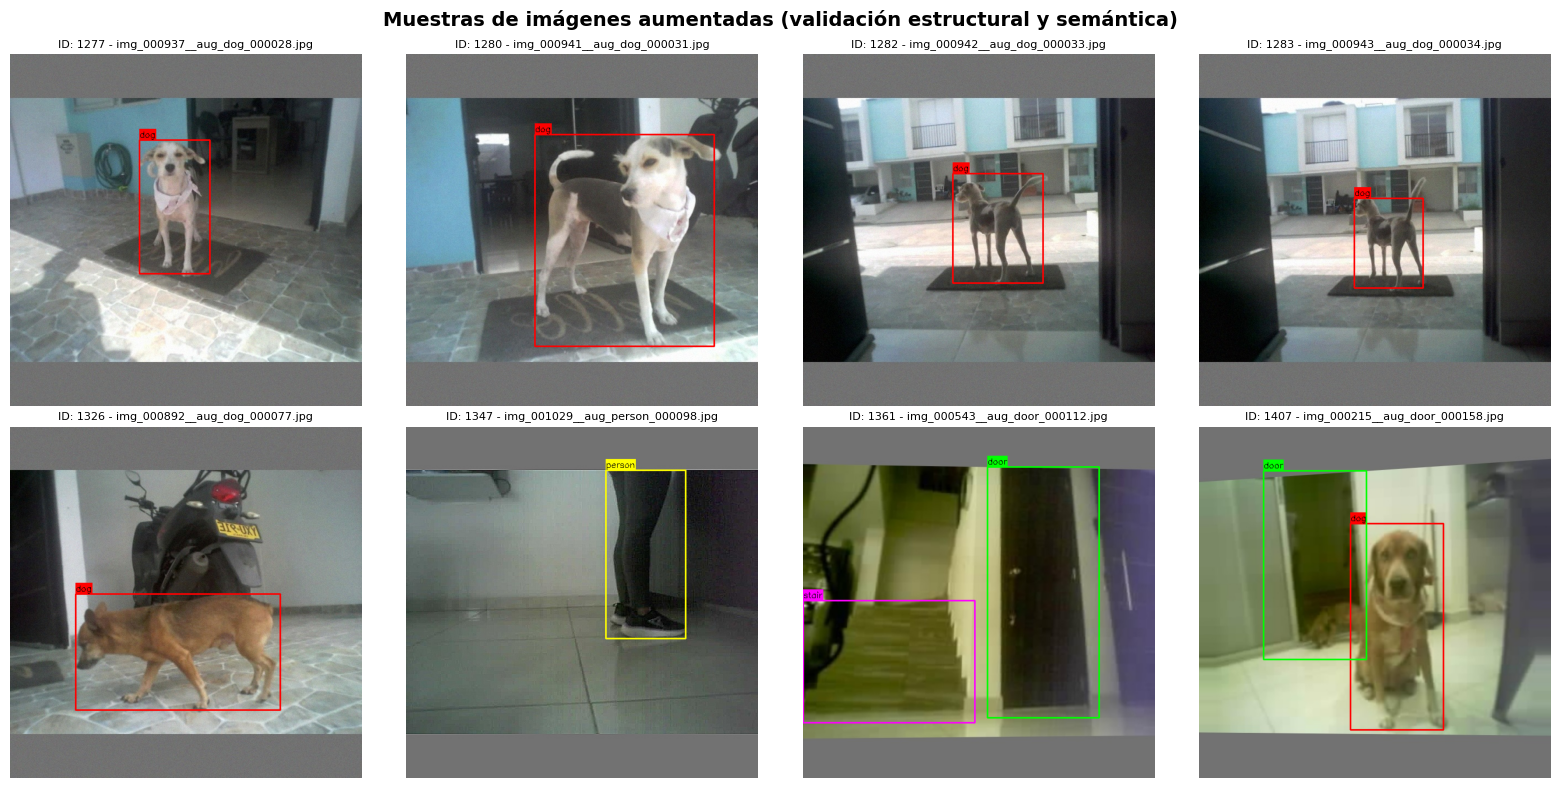

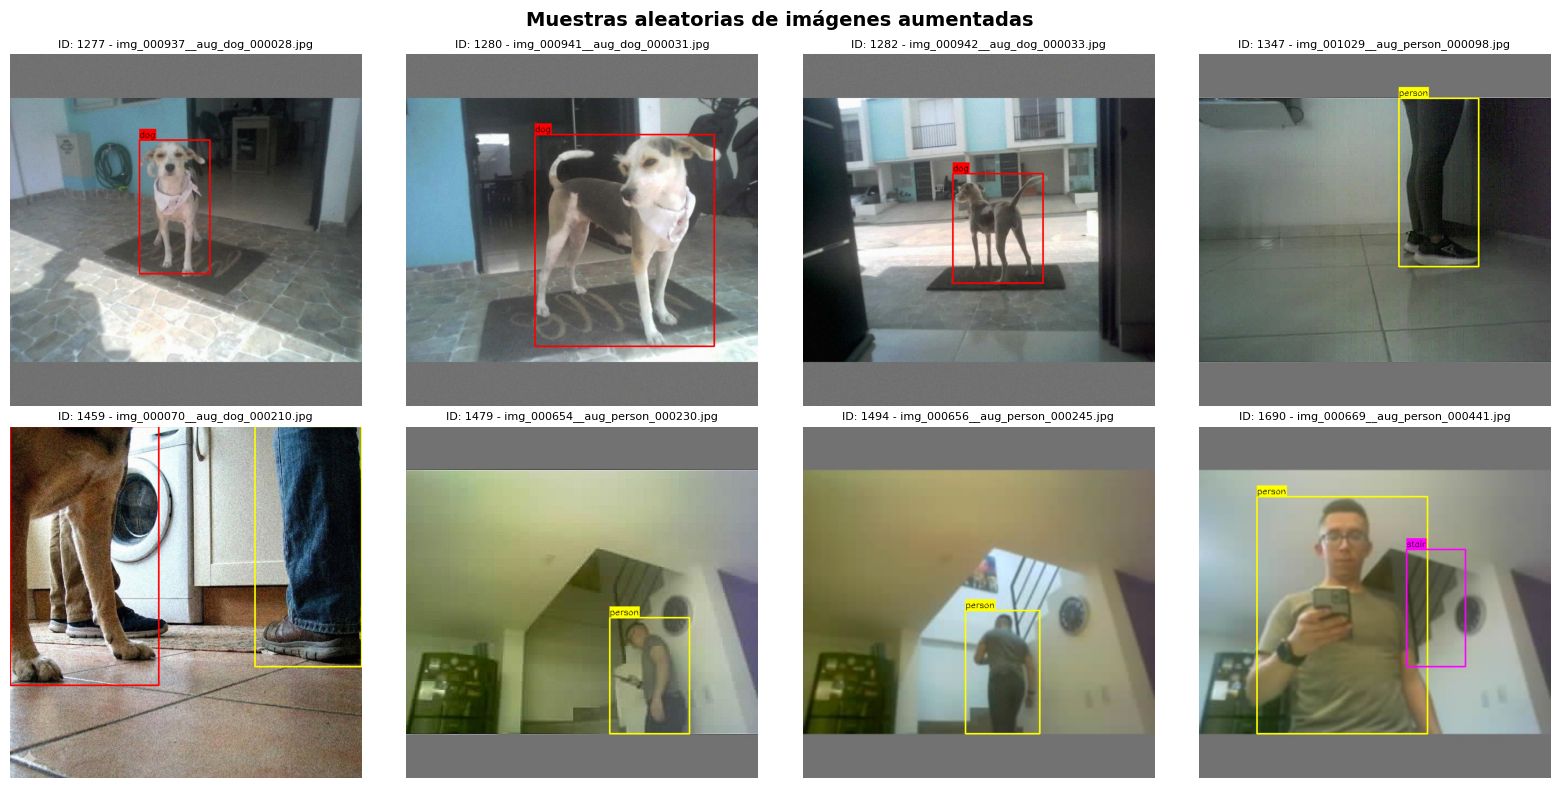

In [49]:
# Visual QA de imágenes nuevas de augmentación usando visualize_sample()
if "compare_ctx" not in globals() or "augmented_ids_info" not in globals():
    raise RuntimeError("Ejecuta primero las celdas de setup y comparación before/after.")

if not augmented_ids_info["augmented_ids"]:
    print("⚠️ No se detectaron imágenes nuevas para visualización.")
else:
    review_samples = sample_augmented_image_ids_for_review(
        after_coco=compare_ctx["coco_after"],
        augmented_img_ids=augmented_ids_info["augmented_ids"],
        per_class=3,
        random_k=12,
        seed=42,
    )

    print("\n🧪 Muestreo para revisión visual")
    print(f"- Estratificadas por clase: {len(review_samples['stratified_ids'])}")
    print(f"- Aleatorias globales: {len(review_samples['random_ids'])}")
    print(f"- Total final (únicas): {len(review_samples['final_ids'])}")

    target_cat_ids_after = compare_ctx["cat_ids_after"]
    id_to_name_after = compare_ctx["id_to_name_after"]

    color_pool = [
        (255, 0, 0),
        (0, 255, 0),
        (0, 0, 255),
        (255, 255, 0),
        (255, 0, 255),
        (0, 255, 255),
        (128, 0, 255),
        (255, 128, 0),
    ]
    class_names_after = [id_to_name_after[cid] for cid in target_cat_ids_after]
    class_colors_after = {
        cls_name: color_pool[i % len(color_pool)]
        for i, cls_name in enumerate(class_names_after)
    }

    visualize_sample(
        coco=compare_ctx["coco_after"],
        target_cat_ids=target_cat_ids_after,
        id_to_name=id_to_name_after,
        class_colors=class_colors_after,
        img_dir=train_after_images_dir,
        img_ids=review_samples["final_ids"][:8],
        filename="09_before_after_visual_augmented_samples",
        title="Muestras de imágenes aumentadas (validación estructural y semántica)"
    )

    # Vista rápida solo aleatoria para control adicional
    if review_samples["random_ids"]:
        visualize_sample(
            coco=compare_ctx["coco_after"],
            target_cat_ids=target_cat_ids_after,
            id_to_name=id_to_name_after,
            class_colors=class_colors_after,
            img_dir=train_after_images_dir,
            img_ids=review_samples["random_ids"][:8],
            filename="09_before_after_visual_augmented_random_only",
            title="Muestras aleatorias de imágenes aumentadas"
        )

## Resultados de la Aumentación Offline del Set Train

1) Hallazgos cuantitativos principales

- La fase de aumentación offline cumplió su objetivo de balanceo por clase, elevando las clases minoritarias al entorno del umbral de referencia (545 instancias): `dog` = 545, `door` = 545, `person` = 545 y `stair` = 548.
- La clase `obstacle`, inicialmente mayoritaria, aumentó de 545 a 561 (**+16**), lo que evidencia un crecimiento colateral acotado.
- El set de entrenamiento se expandió de forma consistente de **874 a 1470 imágenes** y de **1671 a 2744 anotaciones**, manteniendo invariantes las **5 categorías** originales.
- La comparativa de densidad imagen-objeto y de ratio objetos/imagen sugiere una mejora de cobertura en clases débiles sin alterar de forma drástica la estructura estadística de escena.

2) Evidencia del control de cascada por co-ocurrencia

- La matriz de co-ocurrencia before/after muestra el incremento esperado en combinaciones entre clases por efecto de replicación aumentada.
- No obstante, el crecimiento en pares asociados a `obstacle` se mantiene bajo en términos relativos, lo cual es consistente con la lógica de freno por cascada implementada.
- En consecuencia, se observa **balanceo efectivo** sin inflado descontrolado de la clase originalmente dominante.

3) Validación estructural del dataset (COCO)

- La auditoría de integridad before/after reportó **0 errores críticos**.
- No se detectaron IDs duplicados, referencias inválidas (`image_id` / `category_id`), bboxes fuera de rango, inconsistencias de área ni archivos de imagen faltantes/no legibles.
- Estos resultados respaldan que la pipeline preservó correctamente la consistencia formal del dataset.

4) Estabilidad geométrica y complejidad de escena

- Las métricas geométricas complementarias (área, mediana, aspect ratio y tamaños COCO) conservaron patrones globales similares entre before y after.
- Los mapas espaciales de localización de objetos mantienen una distribución coherente con el comportamiento original del dataset.
- En complejidad de escena y oclusión, la mediana de objetos por imagen se mantuvo estable y la variación media de IoU vecinas fue mínima, sin señales de degradación estructural relevante.

5) Validación visual y semántica de muestras aumentadas

- La inspección visual estratificada y aleatoria de imágenes nuevas mostró alineación adecuada entre objeto y bbox en los casos revisados.
- Las transformaciones aplicadas (flip horizontal + transformación específica por clase) preservan la coherencia semántica general de las anotaciones.

6) Implicaciones para entrenamiento y riesgos residuales

- El nuevo train set queda mejor condicionado para entrenamiento en escenarios Edge AI, al reducir el sesgo por desbalance interclase y aumentar la cobertura efectiva de clases críticas.
- Como mejora menor no bloqueante, queda pendiente ajustar el warning de `seaborn` asociado al uso de `palette` sin `hue` en algunos boxplots para asegurar compatibilidad futura.

Conclusión

En conjunto, la estrategia de aumentación offline implementada **mejora significativamente el balance interclase sin comprometer la integridad estructural del dataset ni la coherencia geométrica/semántica de las anotaciones**, por lo que el set Train resultante se considera apto para la siguiente fase de entrenamiento del detector.

---

## Paso 6: Guardar el Dataset Preprocesado en Formato YOLO, COCO y TFrecord 

Para su uso en diferentes frameworks de entrenamiento, se guardará el dataset preprocesado en los siguientes formatos:

* **YOLO:** Se guardará en formato YOLO, que es ampliamente utilizado para tareas de detección de objetos. Este formato consiste en archivos de texto donde cada línea representa una anotación con la clase y las coordenadas normalizadas del bounding box.
* **COCO:** Se guardará en formato COCO, que es un estándar para datasets de detección de objetos. Este formato utiliza un archivo JSON que contiene información sobre las imágenes, las anotaciones y las categorías.
* **TFRecord:** Se guardará en formato TFRecord, que es un formato optimizado para TensorFlow. Este formato permite almacenar grandes cantidades de datos de manera eficiente y es especialmente útil para el entrenamiento de modelos en TensorFlow.





In [1]:
# Paso 6 - Exportar dataset final a COCO / YOLO / TFRecord
# Recarga explícita del módulo para usar siempre la última versión.

import os
import sys
import importlib

if "base_dir" not in globals():
    base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

src_path = os.path.join(base_dir, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import utils_preprocessing as up
up = importlib.reload(up)

source_split_root = os.path.join(
    base_dir,
    "Datasets",
    "dataset_IODC_original_3",
    "dataset_split",
)

output_root = os.path.abspath(
    os.path.join(base_dir, "..", "02_ING_MODELOS", "datasets", "IODC")
)

paths_cfg = up.DatasetExportPathsConfig(
    train_split_dir=os.path.join(source_split_root, "train_augmented_offline_v1"),
    valid_split_dir=os.path.join(source_split_root, "valid"),
    test_split_dir=os.path.join(source_split_root, "test"),
    output_root_dir=output_root,
    include_empty_yolo_labels=True,
    tfrecord_shards=1,
)

mapping_cfg = up.DatasetClassMappingConfig(
    yolo_zero_based=True,
    tfrecord_one_based=True,
)

export_summary = up.export_dataset_all_formats(
    paths_cfg=paths_cfg,
    mapping_cfg=mapping_cfg,
    export_coco=True,
    export_yolo=True,
    export_tfrecord=True,
)

up.print_dataset_export_summary(export_summary)
export_summary

📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/tfrecord/train
📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/tfrecord/valid
📁 Directorio creado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/tfrecord/test

✅ Exportación de dataset completada
   📦 Output root: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC
   🧭 Mapping de clases:
      COCO[0]=dog -> YOLO[0], TF[1]
      COCO[1]=door -> YOLO[1], TF[2]
      COCO[2]=obstacle -> YOLO[2], TF[3]
      COCO[3]=person -> YOLO[3], TF[4]
      COCO[4]=stair -> YOLO[4], TF[5]

   📁 Formato COCO: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/coco
      - train: images=1470, annotations=2744
      - valid: images=188, annotations=762
      - test: images=187, annotations=576

   📁 Formato YOLO: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/yolo
      - train: images=1470, labels=1470, objects=2744
      - valid: images=1

{'output_root_dir': '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC',
 'source_splits': {'train': '/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/train_augmented_offline_v1',
  'valid': '/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/valid',
  'test': '/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_3/dataset_split/test'},
 'class_mapping': {'categories': [{'coco_id': 0,
    'name': 'dog',
    'yolo_id': 0,
    'tfrecord_id': 1},
   {'coco_id': 1, 'name': 'door', 'yolo_id': 1, 'tfrecord_id': 2},
   {'coco_id': 2, 'name': 'obstacle', 'yolo_id': 2, 'tfrecord_id': 3},
   {'coco_id': 3, 'name': 'person', 'yolo_id': 3, 'tfrecord_id': 4},
   {'coco_id': 4, 'name': 'stair', 'yolo_id': 4, 'tfrecord_id': 5}]},
 'formats': {'coco': {'root_dir': '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/IODC/coco',
   'splits': {'train': {'json_path': '/Users/admin/Doc

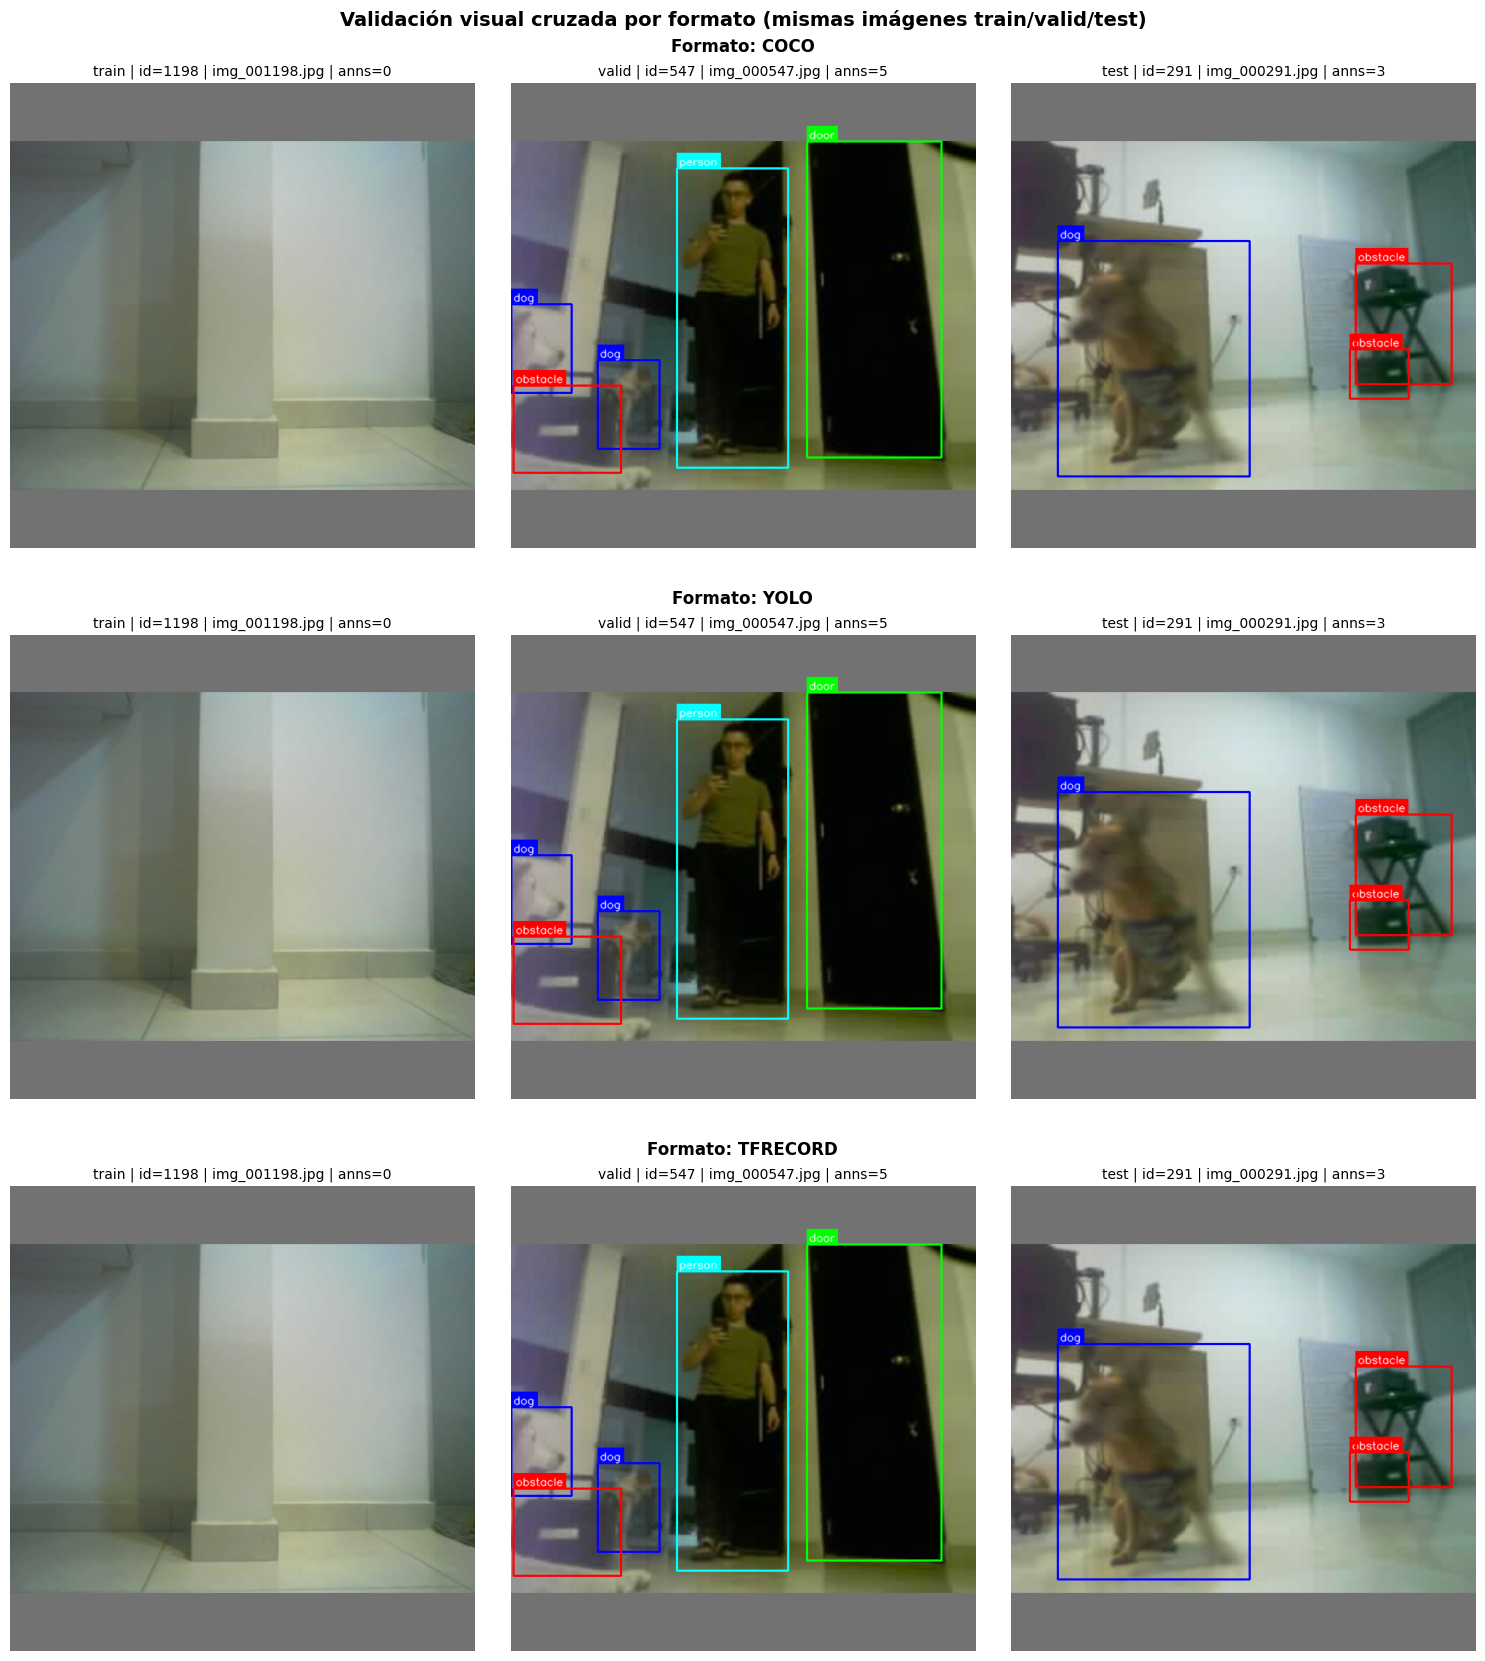


🧪 Validación post-export
   Estado global: PASS
   - COCO: PASS
   - YOLO: PASS
   - TFRECORD: PASS
   ✅ Sin inconsistencias críticas en los checks ejecutados


In [6]:
# Paso 7 - Validación post-export automática (sanity checks + muestreo visual cruzado)

import importlib
import utils_preprocessing as up

up = importlib.reload(up)

if "export_summary" not in globals():
    raise RuntimeError("Primero ejecuta la celda de exportación (Paso 6).")

validation_report = up.validate_exported_dataset_postcheck(
    export_summary=export_summary,
    samples_per_split=1,  # comparación cruzada: 1 imagen train + 1 valid + 1 test
    seed=None,            # aleatorio en cada ejecución; usa un int para fijar reproducibilidad
    show_visual_samples=True,
    save_visual_samples=False,  # cambia a True si quieres guardar imágenes de muestra
)

# validation_report